**Introdução**

*O que é Análise Exploratória de Dados (EDA)?*

Análise Exploratória de Dados, ou EDA, é o processo de entender conjuntos de dados resumindo suas principais características, frequentemente utilizando visualizações. Essa etapa é crucial, especialmente ao modelar os dados para aplicar aprendizado de máquina. A EDA inclui gráficos como histogramas, box plots, scatter plots e outros.

*Como realizar a Análise Exploratória de Dados?*

A resposta depende do conjunto de dados em questão. Não existe um método único para realizar a EDA. Neste tutorial, vamos empregar alguns dos pricipais métodos e gráficos comuns utilizados no processo de EDA.

*Quais dados vamos utilizar?*

Iremos adotar dados do portal de transparência do Estado de São Paulo, remuneração mensal de servidores públicos ativos.

Referências:
https://www.kaggle.com/code/imoore/intro-to-exploratory-data-analysis-eda-in-python

https://medium.com/@ugursavci/complete-exploratory-data-analysis-using-python-9f685d67d1e4

https://www.kaggle.com/code/ekami66/detailed-exploratory-data-analysis-with-python

https://www.analyticsvidhya.com/blog/2022/07/step-by-step-exploratory-data-analysis-eda-using-python/

Dataset: https://www.transparencia.sp.gov.br/home/Remuneracao

**Importando as bibliotecas**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
%matplotlib inline
sns.set(color_codes=True)

# **Etapa 1- Carregando os dados**

**Carregando os dados**

In [3]:
#Subindo dados para o colab
from google.colab import files
uploaded_files = files.upload()

Saving RemuneracaoAtivos.csv to RemuneracaoAtivos.csv


**Salvando os dados em um dataframe**

In [40]:
df = pd.read_csv('RemuneracaoAtivos.csv', encoding='latin-1', sep=';') #salvando o dataset em um dataframe

**Ok, e agora o que vamos fazer com isso?**

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494243 entries, 0 to 494242
Data columns (total 11 columns):
 #   Column                                   Non-Null Count   Dtype 
---  ------                                   --------------   ----- 
 0   NOME                                     494243 non-null  object
 1   CARGO                                    494243 non-null  object
 2   ORGÃO                                    494243 non-null  object
 3   REMUNERAÇÃO DO MÊS                       494243 non-null  object
 4   FÉRIAS E 13º SALÁRIO                     494243 non-null  object
 5   PAGAMENTOS EVENTUAIS                     494243 non-null  object
 6   LICENÇA PRÊMIO INDENIZADA                494243 non-null  object
 7   ABONO PERMANÊNCIA & OUTRAS INDENIZAÇÕES  494243 non-null  object
 8   REDUTOR SALARIAL                         494243 non-null  object
 9   TOTAL LIQUÍDO (R$)                       494243 non-null  object
 10  GRUPO                                    494

Veja o problema, as variáveis numéricas estão como objeto!

**Antes de olhar vamos realizar uma anonimização (não vamos expor nomes nas análises)**

Solução 1:

In [42]:
import random

primeiros_nomes = ["Ana", "Bruno", "Carlos", "Daniela", "Eduardo", "Fernanda",
                   "Gabriel", "Helena", "Igor", "Juliana", "Lucas", "Mariana"]

sobrenomes = ["Silva", "Souza", "Oliveira", "Santos", "Pereira",
              "Costa", "Rodrigues", "Almeida", "Nascimento"]

def gerar_nome():
    return f"{random.choice(primeiros_nomes)} {random.choice(sobrenomes)}"

df['NOME'] = [gerar_nome() for _ in range(len(df))]

**Vamos ver o dataset agora:**

In [43]:
df.head() #visualizando cabeçalho do dataset

,NOME,CARGO,ORGÃO,REMUNERAÇÃO DO MÊS,FÉRIAS E 13º SALÁRIO,PAGAMENTOS EVENTUAIS,LICENÇA PRÊMIO INDENIZADA,ABONO PERMANÊNCIA & OUTRAS INDENIZAÇÕES,REDUTOR SALARIAL,TOTAL LIQUÍDO (R$),GRUPO
0,Carlos Oliveira,ESTAGIARIO,FUND.PE.ANCHIETA-C.P.RADIO TV.,"1400,00","0,00","0,00","0,00","0,00","0,00","1400,00",ATIVOS
1,Igor Santos,SD 1C PM,POLICIA MILITAR SAO PAULO,"5571,16","4249,80","0,00","0,00","1152,60","0,00","7385,42",ATIVOS
2,Lucas Rodrigues,CAP PM,POLICIA MILITAR SAO PAULO,"17445,85","0,00","0,00","0,00","307,36","0,00","8013,77",ATIVOS
3,Helena Santos,POLICIAL PENAL I,SECRETARIA ADM.PENITENCIARIA,"5481,27","0,00","0,00","0,00","0,00","0,00","3855,71",ATIVOS
4,Eduardo Costa,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,"7791,00","0,00","0,00","0,00","0,00","0,00","5953,34",ATIVOS


**Conhecendo mais sobre o dataset**

In [8]:
df.head(10) # Visualizando primeiras 10 linhas

,NOME,CARGO,ORGÃO,REMUNERAÇÃO DO MÊS,FÉRIAS E 13º SALÁRIO,PAGAMENTOS EVENTUAIS,LICENÇA PRÊMIO INDENIZADA,ABONO PERMANÊNCIA & OUTRAS INDENIZAÇÕES,REDUTOR SALARIAL,TOTAL LIQUÍDO (R$),GRUPO
0,Fernanda Santos,ESTAGIARIO,FUND.PE.ANCHIETA-C.P.RADIO TV.,"1400,00","0,00","0,00","0,00","0,00","0,00","1400,00",ATIVOS
1,Carlos Costa,SD 1C PM,POLICIA MILITAR SAO PAULO,"5571,16","4249,80","0,00","0,00","1152,60","0,00","7385,42",ATIVOS
2,Helena Santos,CAP PM,POLICIA MILITAR SAO PAULO,"17445,85","0,00","0,00","0,00","307,36","0,00","8013,77",ATIVOS
3,Lucas Santos,POLICIAL PENAL I,SECRETARIA ADM.PENITENCIARIA,"5481,27","0,00","0,00","0,00","0,00","0,00","3855,71",ATIVOS
4,Fernanda Costa,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,"7791,00","0,00","0,00","0,00","0,00","0,00","5953,34",ATIVOS
5,Juliana Nascimento,1TEN PM,POLICIA MILITAR SAO PAULO,"16151,29","2470,63","0,00","0,00","768,40","0,00","14625,56",ATIVOS
6,Bruno Costa,CABO PM,POLICIA MILITAR SAO PAULO,"8552,50","3576,06","0,00","7937,78","922,08","0,00","16383,10",ATIVOS
7,Mariana Costa,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,"8473,06","0,00","0,00","0,00","0,00","0,00","4957,61",ATIVOS
8,Juliana Costa,ANALISTA GESTAO ORGANIZACIONAL,CIA.PROCES.DAD.EST.SP PRODESP,"17478,15","0,00","70,50","0,00","0,00","0,00","10890,74",ATIVOS
9,Gabriel Almeida,AGENTE DE AP SOCIOEDUCAT III,FUNDACAO CASA-SP.,"11648,12","0,00","0,00","0,00","0,00","0,00","6997,28",ATIVOS


In [9]:
df.tail(5)  # Visualizando ultimas cinco colunas

,NOME,CARGO,ORGÃO,REMUNERAÇÃO DO MÊS,FÉRIAS E 13º SALÁRIO,PAGAMENTOS EVENTUAIS,LICENÇA PRÊMIO INDENIZADA,ABONO PERMANÊNCIA & OUTRAS INDENIZAÇÕES,REDUTOR SALARIAL,TOTAL LIQUÍDO (R$),GRUPO
494238,Gabriel Pereira,OFICIAL ADMINISTRATIVO,DEPT.ESTAD.TRANSITO DETRAN SP,"3469,96","0,00","0,00","0,00","241,20","0,00","3102,80",ATIVOS
494239,Juliana Santos,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,"5328,71","0,00","0,00","0,00","0,00","0,00","4660,62",ATIVOS
494240,Bruno Pereira,PROFESSOR EDUCACAO BASICA I,SECRETARIA DA EDUCACAO,"5681,13","2840,56","0,00","0,00","0,00","0,00","7081,61",ATIVOS
494241,Mariana Rodrigues,CABO PM,POLICIA MILITAR SAO PAULO,"7937,78","0,00","0,00","0,00","1075,76","0,00","5056,37",ATIVOS
494242,Igor Souza,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,"8332,18","0,00","0,00","0,00","0,00","0,00","4957,27",ATIVOS


In [10]:
df

,NOME,CARGO,ORGÃO,REMUNERAÇÃO DO MÊS,FÉRIAS E 13º SALÁRIO,PAGAMENTOS EVENTUAIS,LICENÇA PRÊMIO INDENIZADA,ABONO PERMANÊNCIA & OUTRAS INDENIZAÇÕES,REDUTOR SALARIAL,TOTAL LIQUÍDO (R$),GRUPO
0,Fernanda Santos,ESTAGIARIO,FUND.PE.ANCHIETA-C.P.RADIO TV.,"1400,00","0,00","0,00","0,00","0,00","0,00","1400,00",ATIVOS
1,Carlos Costa,SD 1C PM,POLICIA MILITAR SAO PAULO,"5571,16","4249,80","0,00","0,00","1152,60","0,00","7385,42",ATIVOS
2,Helena Santos,CAP PM,POLICIA MILITAR SAO PAULO,"17445,85","0,00","0,00","0,00","307,36","0,00","8013,77",ATIVOS
3,Lucas Santos,POLICIAL PENAL I,SECRETARIA ADM.PENITENCIARIA,"5481,27","0,00","0,00","0,00","0,00","0,00","3855,71",ATIVOS
4,Fernanda Costa,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,"7791,00","0,00","0,00","0,00","0,00","0,00","5953,34",ATIVOS
...,...,...,...,...,...,...,...,...,...,...,...
494238,Gabriel Pereira,OFICIAL ADMINISTRATIVO,DEPT.ESTAD.TRANSITO DETRAN SP,"3469,96","0,00","0,00","0,00","241,20","0,00","3102,80",ATIVOS
494239,Juliana Santos,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,"5328,71","0,00","0,00","0,00","0,00","0,00","4660,62",ATIVOS
494240,Bruno Pereira,PROFESSOR EDUCACAO BASICA I,SECRETARIA DA EDUCACAO,"5681,13","2840,56","0,00","0,00","0,00","0,00","7081,61",ATIVOS
494241,Mariana Rodrigues,CABO PM,POLICIA MILITAR SAO PAULO,"7937,78","0,00","0,00","0,00","1075,76","0,00","5056,37",ATIVOS


# **Etapa 2 - Limpeza dos dados**

**Acertando nome das colunas**

Nós vamos remover caracteres complexos dos nomes das colunas

In [44]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('(', '')
    .str.replace(')', '')
)

**Vamos verificar nossos dados** - **lembre-se:** *nunca confiar!*

---



In [12]:
# Verificando dados
print ("Tabela 1 - Verificação de dados")
print(df.info())
print("\n") #paragráfo entre os resultados

# Verificando se há algum valor vazio
print ("Tabela 2 - Verificação de dados vazios")
print(df.isna().any())
print("\n")

# Verificando quantidade de dados vazios
print ("Tabela 3 - Verificação de quantidade de dados vazios")
print(df.isna().sum())
print("\n")

Tabela 1 - Verificação de dados
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494243 entries, 0 to 494242
Data columns (total 11 columns):
 #   Column                                   Non-Null Count   Dtype 
---  ------                                   --------------   ----- 
 0   nome                                     494243 non-null  object
 1   cargo                                    494243 non-null  object
 2   orgão                                    494243 non-null  object
 3   remuneração_do_mês                       494243 non-null  object
 4   férias_e_13º_salário                     494243 non-null  object
 5   pagamentos_eventuais                     494243 non-null  object
 6   licença_prêmio_indenizada                494243 non-null  object
 7   abono_permanência_&_outras_indenizações  494243 non-null  object
 8   redutor_salarial                         494243 non-null  object
 9   total_liquído_r$                         494243 non-null  object
 10  grupo       

**Os números que observamos estão sendo entendidos como texto, vamos arrumar.**

In [45]:
# Selecionando as colunas numéricas
colunas_numericas = [
    'remuneração_do_mês',
    'férias_e_13º_salário',
    'pagamentos_eventuais',
    'licença_prêmio_indenizada',
    'abono_permanência_&_outras_indenizações',
    'redutor_salarial',
    'total_liquído_r$'
]

In [47]:
# Convertendo texto para números decimais, removendo espaços e mudando de , para . o separador de decimal
def converter_moeda(coluna):
    return (
        coluna.astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
        .astype(float)
    )

In [48]:
#Aplicando para todas as colunas numéricas
for col in colunas_numericas:
    df[col] = converter_moeda(df[col])

Pronto, vamos verificar se funcionou:

In [49]:
df.dtypes

,0
nome,object
cargo,object
orgão,object
remuneração_do_mês,float64
férias_e_13º_salário,float64
pagamentos_eventuais,float64
licença_prêmio_indenizada,float64
abono_permanência_&_outras_indenizações,float64
redutor_salarial,float64
total_liquído_r$,float64


**Limpeza do dataset**

**Removendo colunas do dataset**

Pode ser interessante remover colunas do dataset para facilitar a visualização gráfica dos dados, ou para a realização de análises. Nesse caso poderíamos remover a coluna grupo, pois ela não revela muita coisa.

In [50]:
df = df.drop(['grupo'], axis=1)
df.head(5)

,nome,cargo,orgão,remuneração_do_mês,férias_e_13º_salário,pagamentos_eventuais,licença_prêmio_indenizada,abono_permanência_&_outras_indenizações,redutor_salarial,total_liquído_r$
0,Carlos Oliveira,ESTAGIARIO,FUND.PE.ANCHIETA-C.P.RADIO TV.,1400.00,0.0,0.0,0.0,0.00,0.0,1400.00
1,Igor Santos,SD 1C PM,POLICIA MILITAR SAO PAULO,5571.16,4249.8,0.0,0.0,1152.60,0.0,7385.42
2,Lucas Rodrigues,CAP PM,POLICIA MILITAR SAO PAULO,17445.85,0.0,0.0,0.0,307.36,0.0,8013.77
3,Helena Santos,POLICIAL PENAL I,SECRETARIA ADM.PENITENCIARIA,5481.27,0.0,0.0,0.0,0.00,0.0,3855.71
4,Eduardo Costa,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,7791.00,0.0,0.0,0.0,0.00,0.0,5953.34


**Verificando e removendo dados duplicados**

In [51]:
#Contabilizando linhas
df.count()

,0
nome,494243
cargo,494243
orgão,494243
remuneração_do_mês,494243
férias_e_13º_salário,494243
pagamentos_eventuais,494243
licença_prêmio_indenizada,494243
abono_permanência_&_outras_indenizações,494243
redutor_salarial,494243
total_liquído_r$,494243


In [52]:
# Verificando dados duplicados
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)

number of duplicate rows:  (34439, 10)


**Está aparecendo que temos mais de 34000 dados dpulicados! Será que é isso mesmo?**

*Vamos ver:*

In [53]:
duplicate_rows_df.head()

,nome,cargo,orgão,remuneração_do_mês,férias_e_13º_salário,pagamentos_eventuais,licença_prêmio_indenizada,abono_permanência_&_outras_indenizações,redutor_salarial,total_liquído_r$
574,Ana Silva,OUTROS VINCULOS,SECRETARIA ADM.PENITENCIARIA,307.36,0.0,0.0,0.0,0.0,0.0,307.36
1173,Igor Silva,OUTROS VINCULOS,SECRETARIA ADM.PENITENCIARIA,307.36,0.0,0.0,0.0,0.0,0.0,307.36
1321,Carlos Pereira,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,5286.75,0.0,0.0,0.0,0.0,0.0,4641.66
2096,Daniela Nascimento,OUTROS VINCULOS,SECRETARIA ADM.PENITENCIARIA,922.08,0.0,0.0,0.0,0.0,0.0,922.08
2149,Helena Rodrigues,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,2086.87,0.0,0.0,0.0,0.0,0.0,1923.36


**Olha aqui o problema, nós randomizamos os nomes!**

In [54]:
df.groupby('nome').size().sort_values(ascending=False).head()

,0
nome,
Daniela Oliveira,4722
Helena Pereira,4718
Gabriel Costa,4700
Mariana Pereira,4692
Fernanda Costa,4688


Solução:

In [55]:
df['id'] = range(len(df))
#Agora sim, cada linha uma identidade

Vamos testar:

In [56]:
# Verificando dados duplicados
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)

number of duplicate rows:  (0, 11)


Não vamos remover, mas seguem os comandos caso precisem no futuro:

In [ ]:
# Removendo dados duplicados
df = df.drop_duplicates()
df.head(5)

In [ ]:
# Contabilizando dados após verificação de dados duplicados
df.count()

**Dados faltantes e nulos**

Nesse exemplo iremos apenas detectar se temos valores ausentes e nulos pois eles podem aparecer no dataset.

Existem abordagens onde poderíamos estimar os valores, substituí-los pela média ou mediana da coluna, além de utilizar outras abordagens para estima-los, com base em teoria de probabilidade. Mas cuidado extremo ao fazer isso, saiba o que você está fazendo, pois estará alterando o dataset com novos dados.

Sempre busque critérios para remoção desses valores, nesse caso não temos, o gorverno do Estado fez um bom trabalho.

In [57]:
# Contando vazios novamente
print(df.isnull().sum())

nome                                       0
cargo                                      0
orgão                                      0
remuneração_do_mês                         0
férias_e_13º_salário                       0
pagamentos_eventuais                       0
licença_prêmio_indenizada                  0
abono_permanência_&_outras_indenizações    0
redutor_salarial                           0
total_liquído_r$                           0
id                                         0
dtype: int64


In [ ]:
# Removendo vazios
df = df.dropna()
print(df.isnull().sum()) # Recontando vazios

# **Etapa 3 - Realização da EDA**

**Realização das análises univariadas**

1. *Estatística descritiva*
2. *Histograma*
3. *Boxplot*
4. *Barplot*

# **1. Estatística descritiva**

Em phyton a função describe() fornece um resumo estatístico. Com isso é possível verificar de forma geral o comportameento da dua amostra, potencial existência de outliers, erros de entrada de dados, e a distribuição dos dados, se são normalmente distribuídos ou assimétricos para a esquerda/direita.

A função describe() fornece um resumo estatístico dos dados numéricos, como int e float."

In [59]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
remuneração_do_mês,494243.0,7307.823259,5833.737103,0.00,4271.575,6465.62,8490.94,226729.46
férias_e_13º_salário,494243.0,538.763526,1962.160589,-15455.39,0.000,0.00,0.00,125399.69
pagamentos_eventuais,494243.0,319.345670,2855.937860,-82683.35,0.000,0.00,0.00,200013.02
licença_prêmio_indenizada,494243.0,65.502028,903.573040,-3967.44,0.000,0.00,0.00,46366.18
abono_permanência_&_outras_indenizações,494243.0,519.853048,2461.879692,-55557.50,0.000,0.00,499.46,286850.36
redutor_salarial,494243.0,-57.002827,1485.288131,-192715.71,0.000,0.00,0.00,0.00
total_liquído_r$,494243.0,5919.614917,6210.785189,-74083.35,3172.150,4791.14,6656.91,336099.30
id,494243.0,247121.000000,142675.808885,0.00,123560.500,247121.00,370681.50,494242.00


**Módulo avançado:**

Porém, podemos ter a necessidade de consultar os parametros de estatística descritiva de forma isolada, ou adicionar mais parametros na analise, para isso podemos utilizar outra abordagem:

Podemos utilizar:
- statistics_summary['median']: Adiciona a mediana das colunas.
- statistics_summary['mode']: Adiciona a moda.
- statistics_summary['range']: Calcula o intervalo.
- statistics_summary['cv']: Calcula o coeficiente de variação (CV).
- statistics_summary['skewness']: Calcula a assimetria.
- statistics_summary['kurtosis']: Calcula a curtose.
- statistics_summary['sem']: Calcula o erro padrão da média (SEM).
- statistics_summary['Q1']: Adiciona o primeiro quartil (25º percentil).
- statistics_summary['Q3']: Adiciona o terceiro quartil (75º percentil).
- statistics_summary['IQR']: Calcula o intervalo interquartil, que é a diferença entre o terceiro e o primeiro quartil.

**Atenção:**
- *Importação Necessária*: Não se esqueça de importar as funções necessárias: from scipy.stats import skew, kurtosis.
- *Filtro de Dados*: É necessário garantir que o dataset não contenha dados não numéricos no DataFrame. Filtre para incluir apenas colunas numéricas.

Essa abordagem fornece um resumo completo das estatísticas do seu DataFrame df, incluindo medidas adicionais que podem ser úteis para uma análise mais aprofundada.


In [60]:
from scipy.stats import skew, kurtosis

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Calculando estatísticas básicas
statistics_summary = numeric_df.describe().T

# Calculando estatísticas adicionais
statistics_summary['median'] = numeric_df.median()
statistics_summary['mode'] = numeric_df.mode().iloc[0]
statistics_summary['range'] = numeric_df.max() - numeric_df.min()
statistics_summary['cv'] = statistics_summary['std'] / statistics_summary['mean']  # Coeficiente de variação
statistics_summary['skewness'] = numeric_df.apply(lambda x: skew(x.dropna()))
statistics_summary['kurtosis'] = numeric_df.apply(lambda x: kurtosis(x.dropna()))
statistics_summary['sem'] = numeric_df.sem()  # Erro padrão da média

# Calculando quartis e intervalo interquartil
quartiles = numeric_df.quantile([0.25, 0.75])
statistics_summary['Q1'] = quartiles.loc[0.25]
statistics_summary['Q3'] = quartiles.loc[0.75]
statistics_summary['IQR'] = statistics_summary['Q3'] - statistics_summary['Q1']

# Visualizando o resumo das estatísticas
statistics_summary = statistics_summary[['count', 'mean', 'std', 'median', 'mode', 'min', 'max', 'range', 'Q1', 'Q3', 'IQR', 'cv', 'skewness', 'kurtosis', 'sem']]

# Formatando todas as colunas para exibir duas casas decimais
statistics_summary = statistics_summary.applymap(lambda x: f"{x:.2f}")

# Exibindo o resumo das estatísticas
statistics_summary

/tmp/ipykernel_10084/440432963.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  statistics_summary = statistics_summary.applymap(lambda x: f"{x:.2f}")


,count,mean,std,median,mode,min,max,range,Q1,Q3,IQR,cv,skewness,kurtosis,sem
remuneração_do_mês,494243.00,7307.82,5833.74,6465.62,7791.00,0.00,226729.46,226729.46,4271.57,8490.94,4219.37,0.80,4.83,55.60,8.30
férias_e_13º_salário,494243.00,538.76,1962.16,0.00,0.00,-15455.39,125399.69,140855.08,0.00,0.00,0.00,3.64,10.02,220.10,2.79
pagamentos_eventuais,494243.00,319.35,2855.94,0.00,0.00,-82683.35,200013.02,282696.37,0.00,0.00,0.00,8.94,32.19,1601.48,4.06
licença_prêmio_indenizada,494243.00,65.50,903.57,0.00,0.00,-3967.44,46366.18,50333.62,0.00,0.00,0.00,13.79,20.88,603.33,1.29
abono_permanência_&_outras_indenizações,494243.00,519.85,2461.88,0.00,0.00,-55557.50,286850.36,342407.86,0.00,499.46,499.46,4.74,21.76,911.23,3.50
redutor_salarial,494243.00,-57.00,1485.29,0.00,0.00,-192715.71,0.00,192715.71,0.00,0.00,0.00,-26.06,-52.98,3997.83,2.11
total_liquído_r$,494243.00,5919.61,6210.79,4791.14,5910.33,-74083.35,336099.30,410182.65,3172.15,6656.91,3484.76,1.05,8.48,151.27,8.83
id,494243.00,247121.00,142675.81,247121.00,0.00,0.00,494242.00,494242.00,123560.50,370681.50,247121.00,0.58,-0.00,-1.20,202.95


# **2. Analisando a distribuição de frequência das variáveis (histograma)**

**Código geral**

array([[<Axes: title={'center': 'remuneração_do_mês'}>,
        <Axes: title={'center': 'férias_e_13º_salário'}>,
        <Axes: title={'center': 'pagamentos_eventuais'}>],
       [<Axes: title={'center': 'licença_prêmio_indenizada'}>,
        <Axes: title={'center': 'abono_permanência_&_outras_indenizações'}>,
        <Axes: title={'center': 'redutor_salarial'}>],
       [<Axes: title={'center': 'total_liquído_r$'}>,
        <Axes: title={'center': 'id'}>, <Axes: >]], dtype=object)

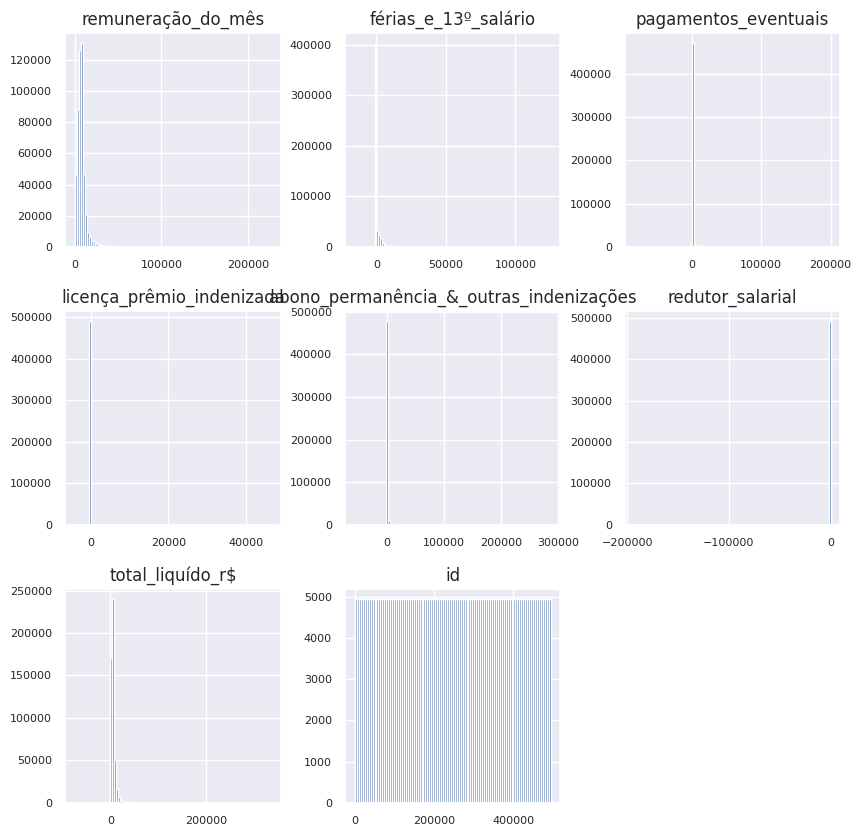

In [63]:
numeric_df.hist(figsize=(10, 10), bins=100, xlabelsize=8, ylabelsize=8)

2.1. Gerando histogramas utilizando a Matplotlib

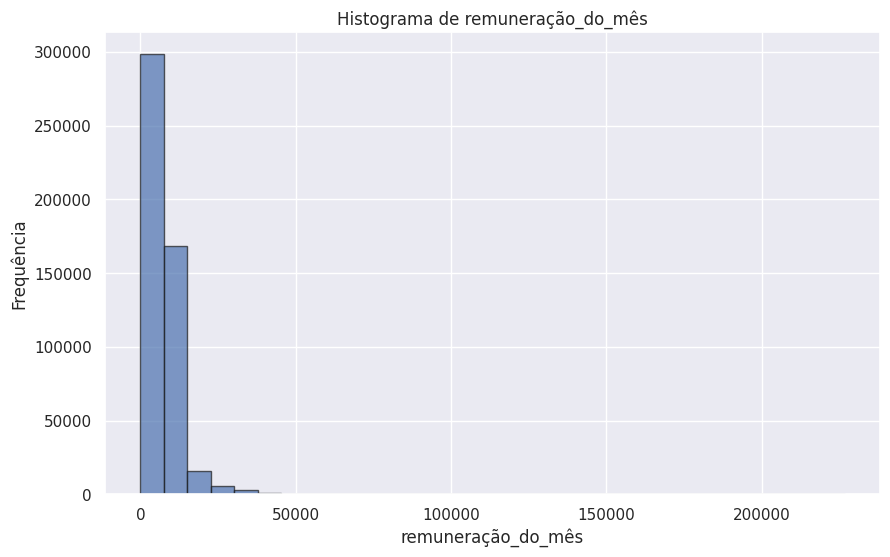

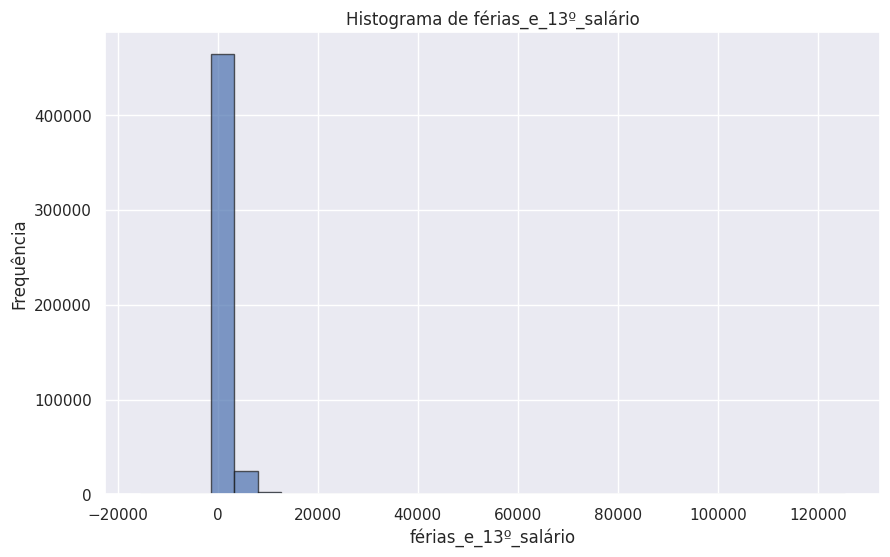

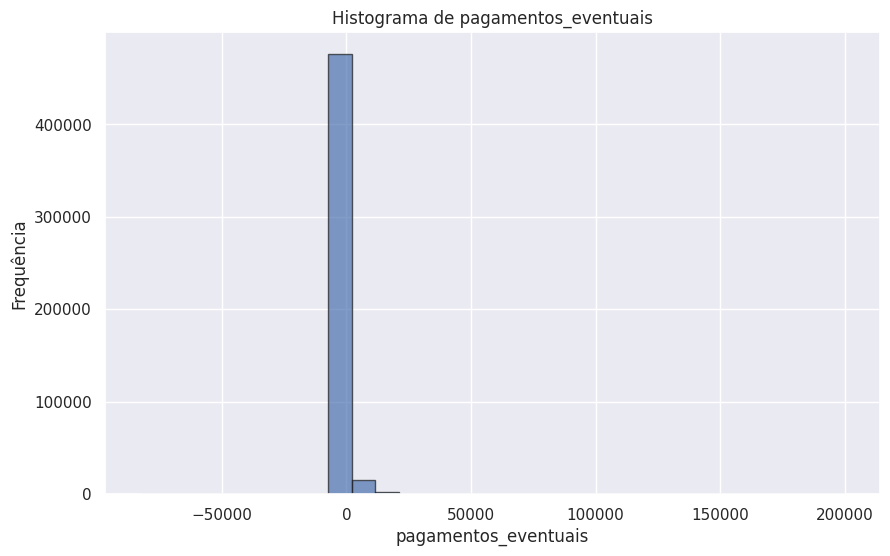

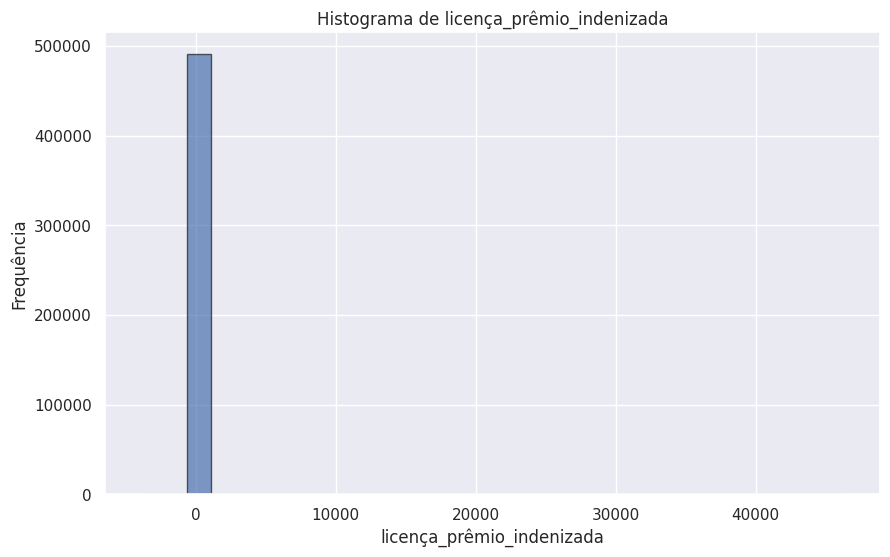

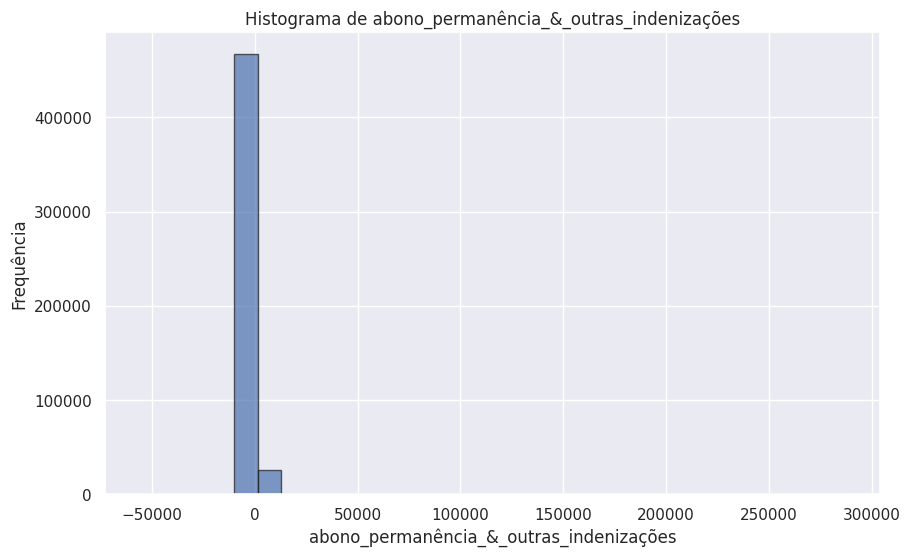

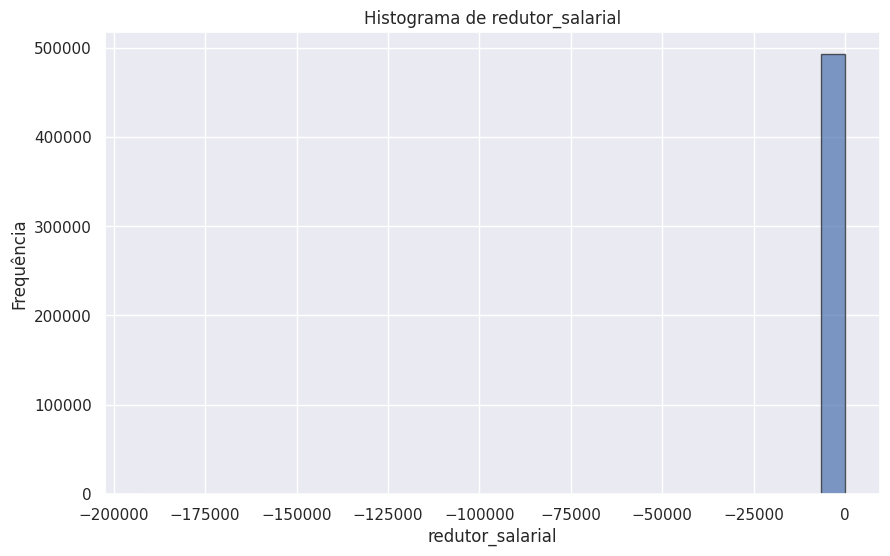

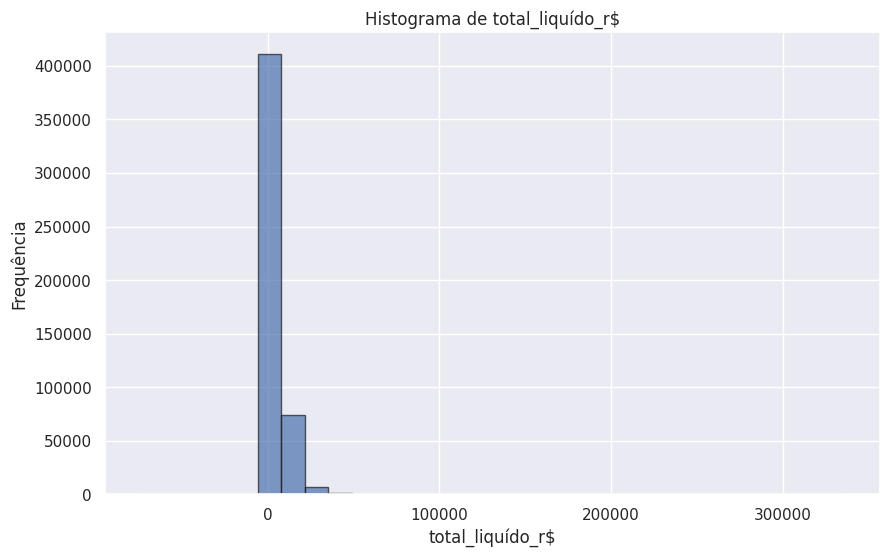

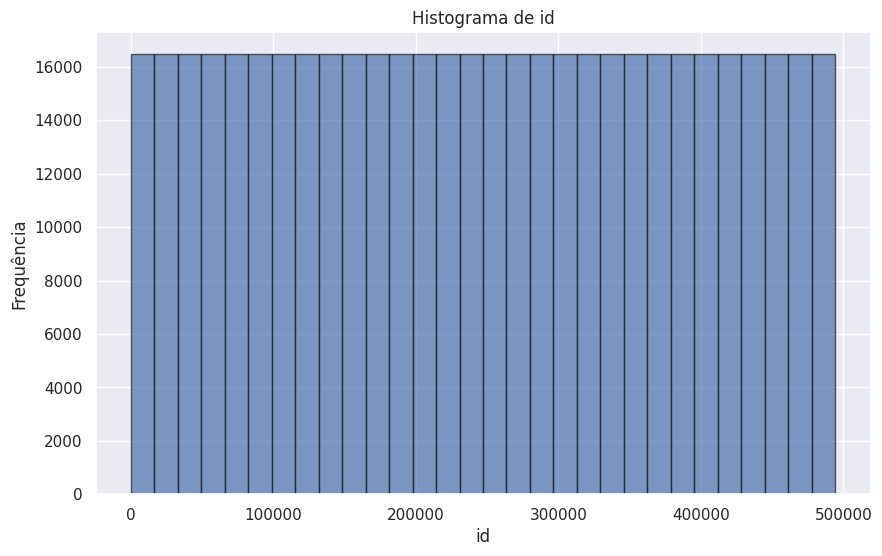

In [64]:
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Gerar histogramas para cada coluna numérica
for column in numeric_df.columns:
    plt.figure(figsize=(10, 6))
    plt.hist(numeric_df[column].dropna(), bins=30, edgecolor='k', alpha=0.7)
    plt.title(f'Histograma de {column}')
    plt.xlabel(column)
    plt.ylabel('Frequência')
    plt.grid(True)
    plt.show()

Gerando histogramas utilizando a Seaborn

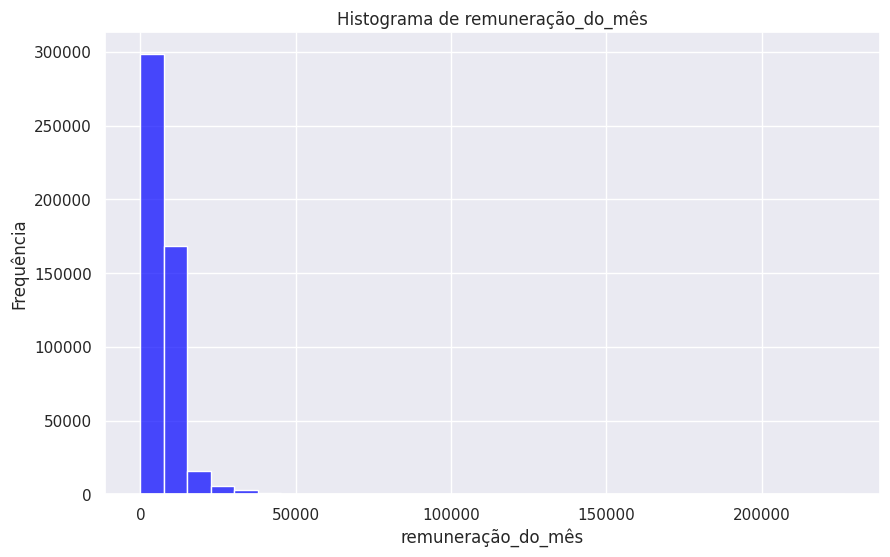

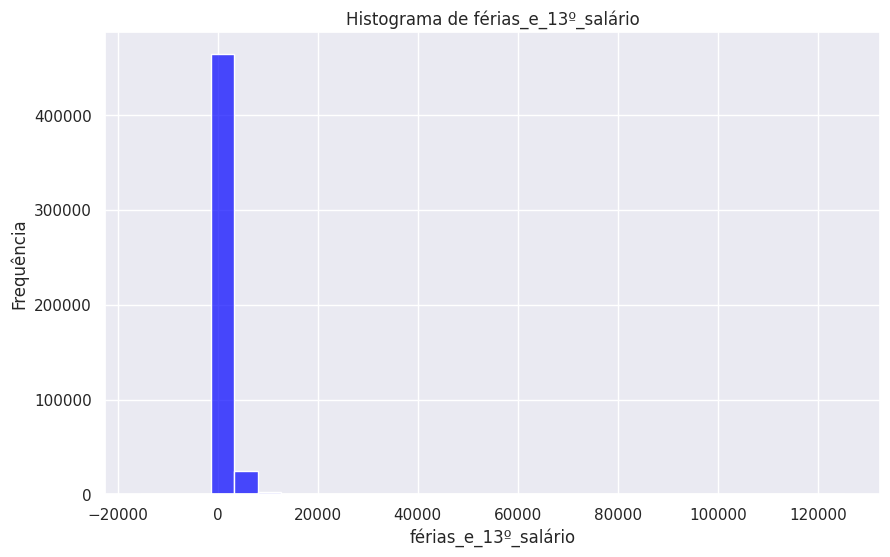

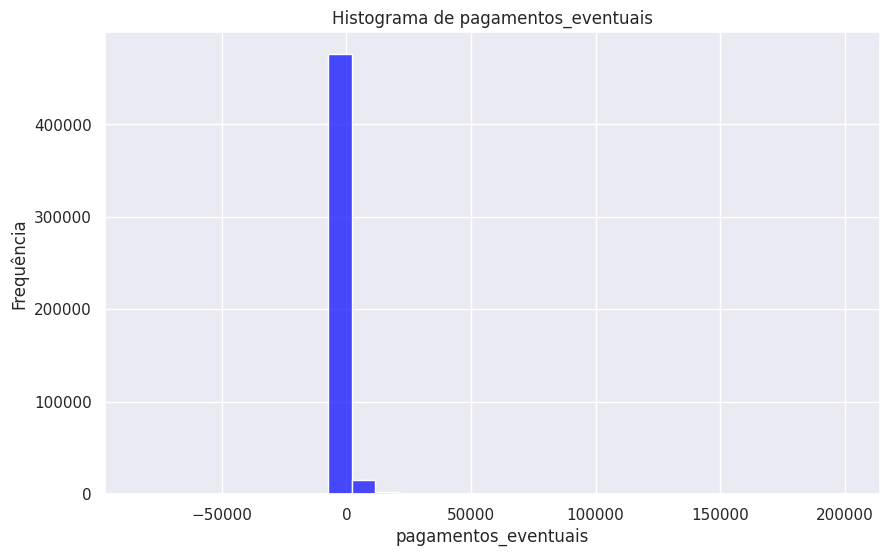

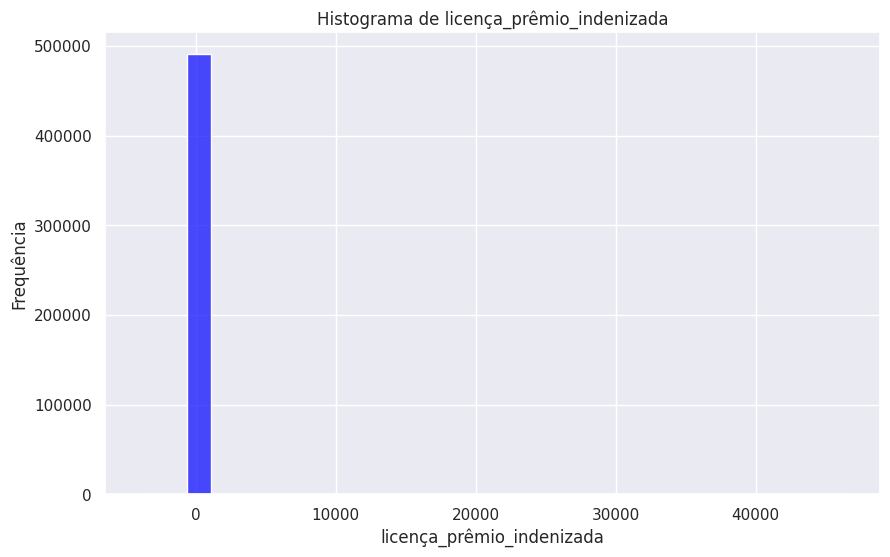

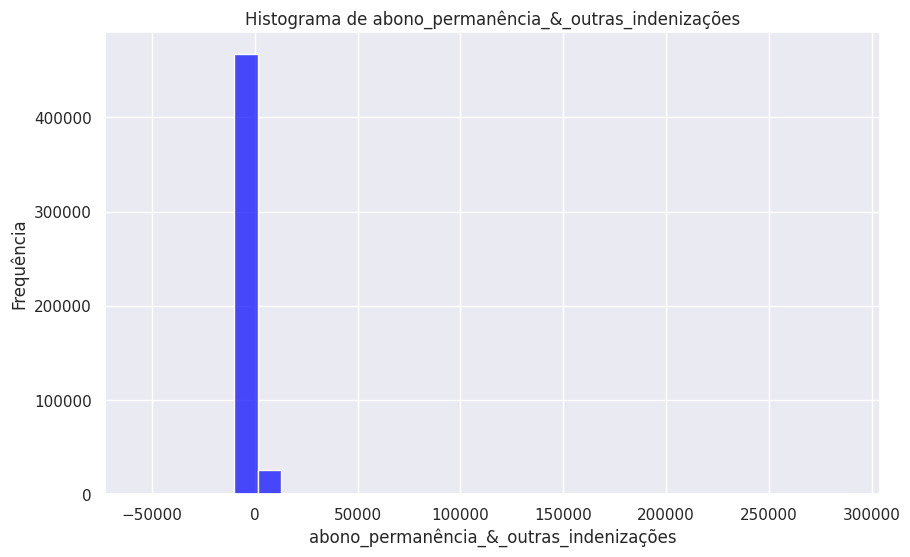

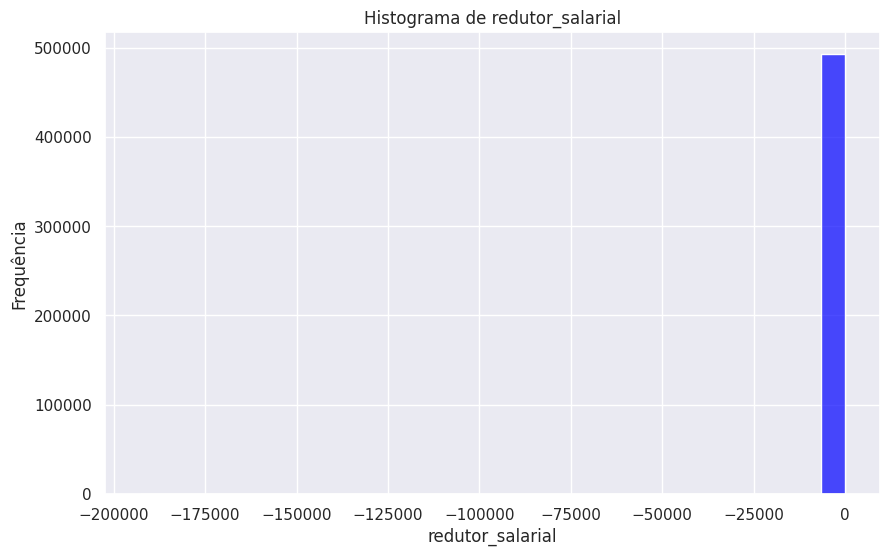

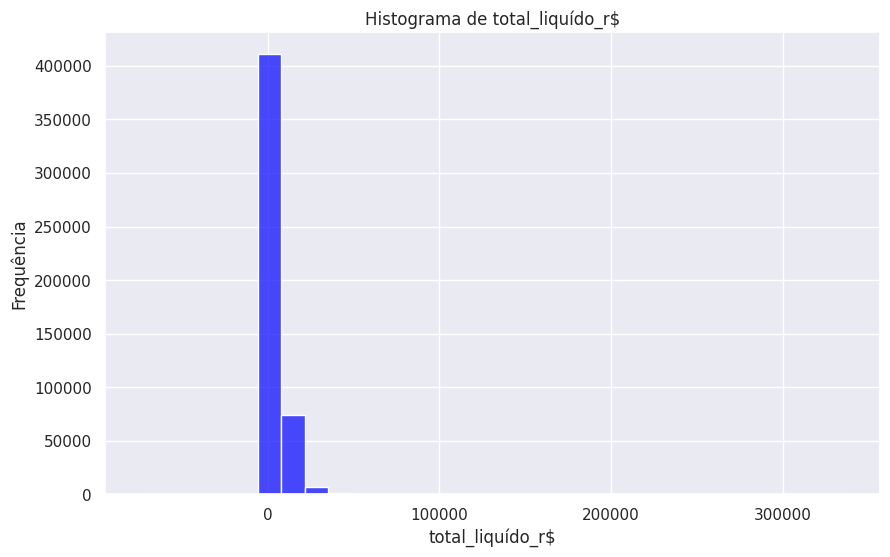

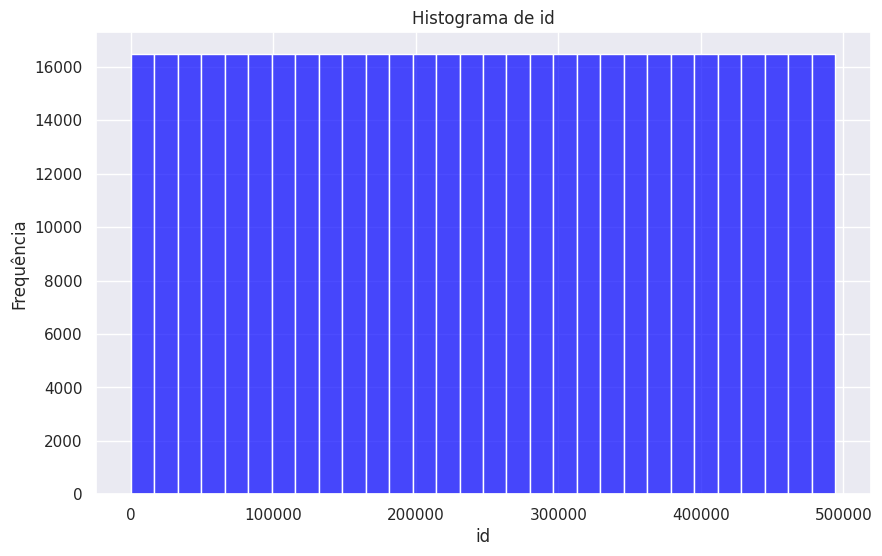

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Gerar histogramas para cada coluna numérica usando seaborn
for column in numeric_df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(numeric_df[column].dropna(), bins=30, kde=False, color='blue', alpha=0.7)
    plt.title(f'Histograma de {column}')
    plt.xlabel(column)
    plt.ylabel('Frequência')
    plt.grid(True)
    plt.show()

**Explicação:**
- plt.hist(): Cria um histograma básico usando matplotlib. O parâmetro bins define o número de intervalos no histograma, e edgecolor define a cor da borda dos bins.
- sns.histplot(): Cria um histograma usando seaborn, que também pode incluir uma estimativa da densidade de kernel (kde=True) se você desejar. O parâmetro color define a cor dos bins.
- O parâmetro alpha em visualizações como histogramas e gráficos de dispersão controla a transparência das barras ou pontos. O valor de alpha varia de 0 a 1, onde:
alpha = 0: Totalmente transparente.
alpha = 1: Totalmente opaco (sem transparência).

Ambos os métodos permitem visualizar a distribuição das variáveis numéricas no seu DataFrame. Ajuste o número de bins e outras opções conforme necessário para obter a visualização desejada.

**Observando em uma linha**

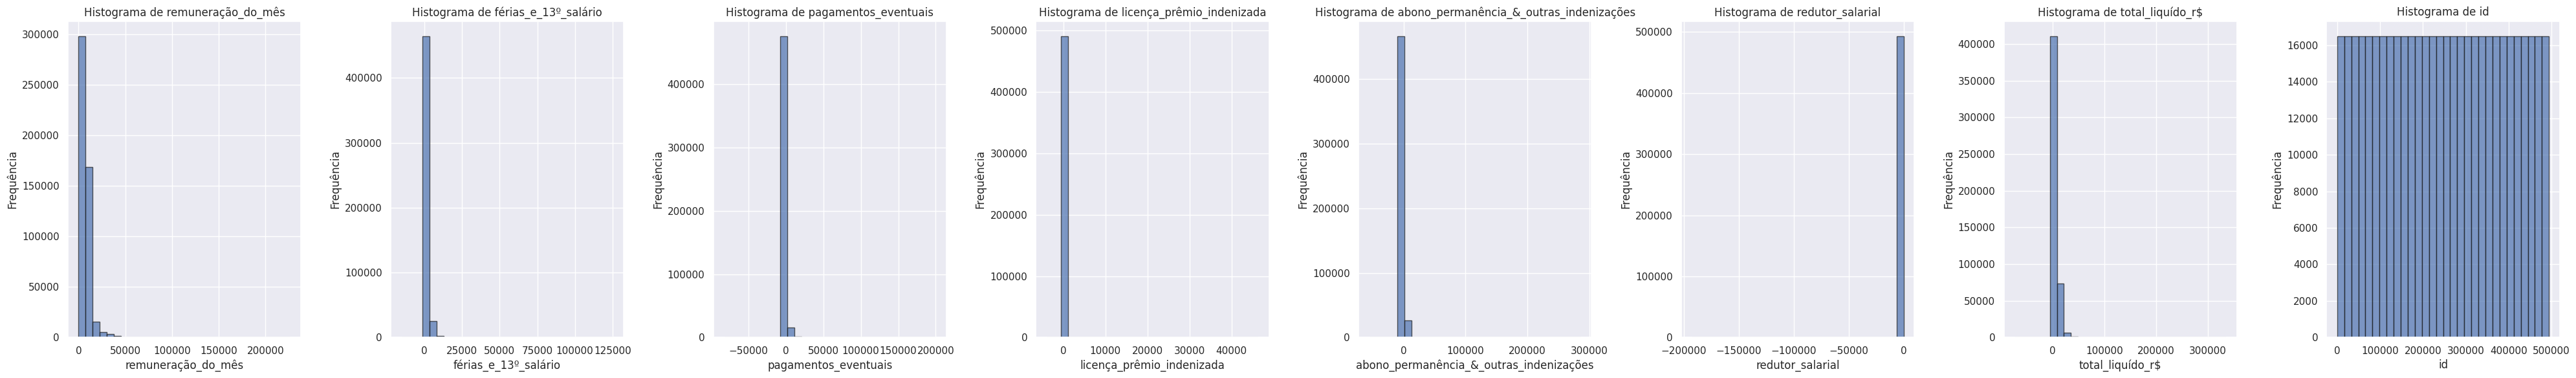

In [66]:
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Definindo o número de subplots com base no número de colunas numéricas
num_vars = len(numeric_df.columns)
fig, axes = plt.subplots(1, num_vars, figsize=(5 * num_vars, 6))  # Ajuste o tamanho conforme necessário

# Gerar histogramas para cada coluna numérica
for ax, column in zip(axes, numeric_df.columns):
    ax.hist(numeric_df[column].dropna(), bins=30, edgecolor='k', alpha=0.7)
    ax.set_title(f'Histograma de {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequência')
    ax.grid(True)

# Ajustar o layout
plt.tight_layout()
plt.show()

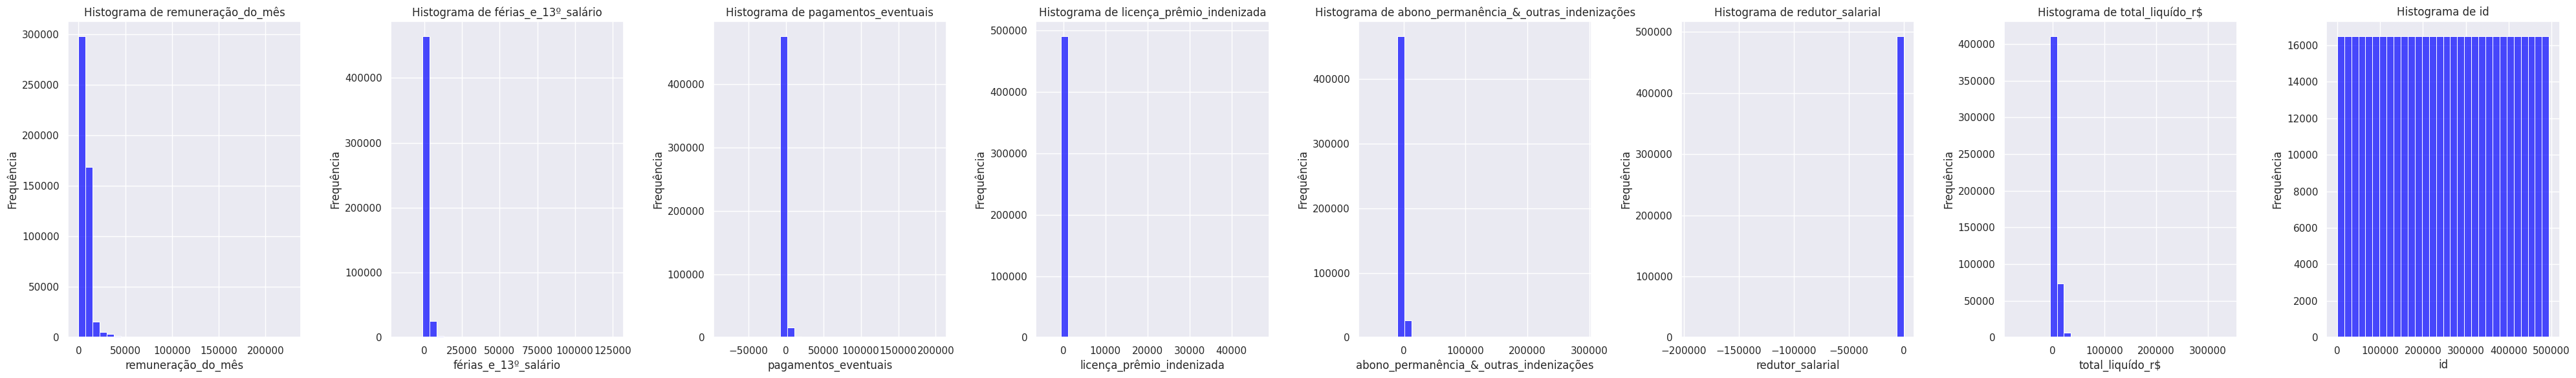

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Definindo o número de subplots com base no número de colunas numéricas
num_vars = len(numeric_df.columns)
fig, axes = plt.subplots(1, num_vars, figsize=(5 * num_vars, 6))  # Ajuste o tamanho conforme necessário

# Gerar histogramas para cada coluna numérica usando seaborn
for ax, column in zip(axes, numeric_df.columns):
    sns.histplot(numeric_df[column].dropna(), bins=30, kde=False, ax=ax, color='blue', alpha=0.7)
    ax.set_title(f'Histograma de {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequência')
    ax.grid(True)

# Ajustar o layout
plt.tight_layout()
plt.show()

# **3. Boxplots**

**Boxplots com Matplotlib**

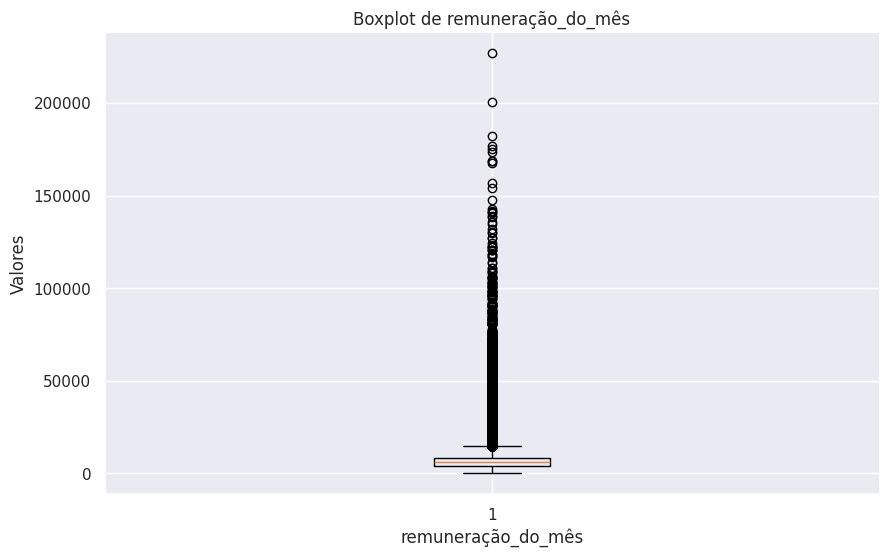

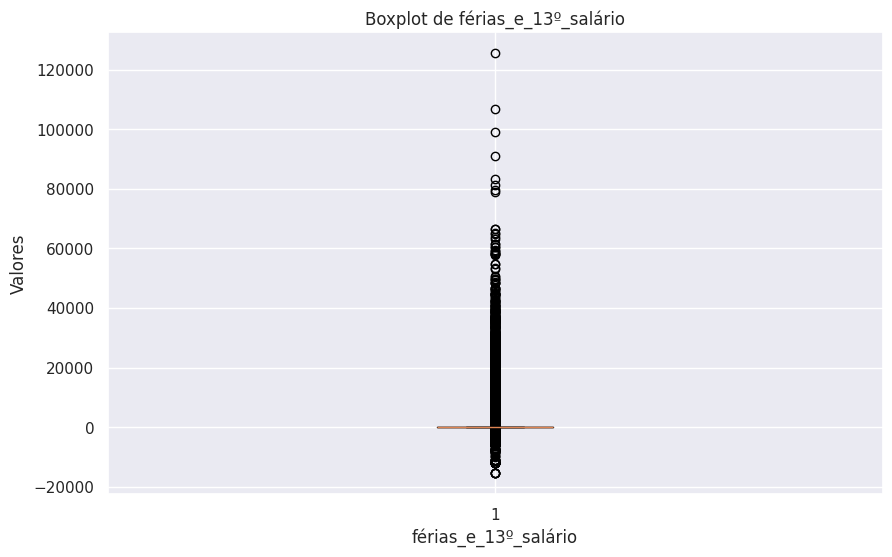

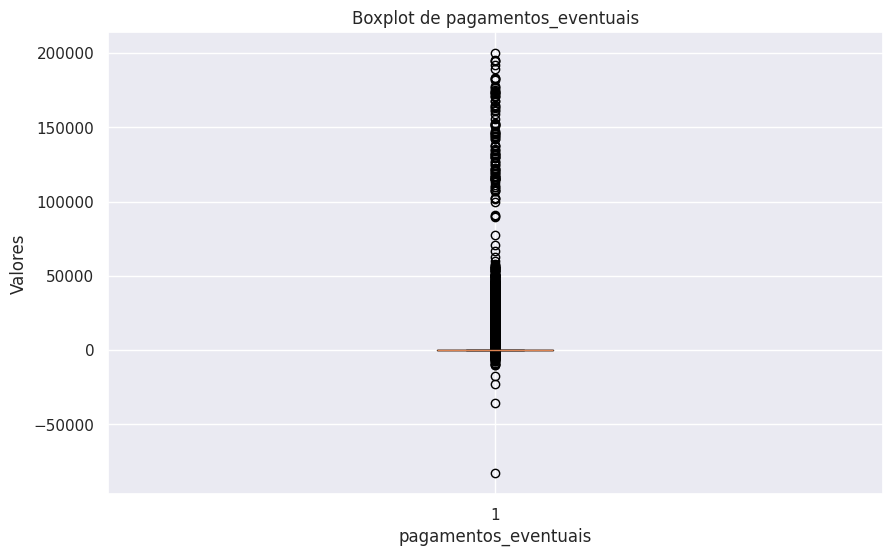

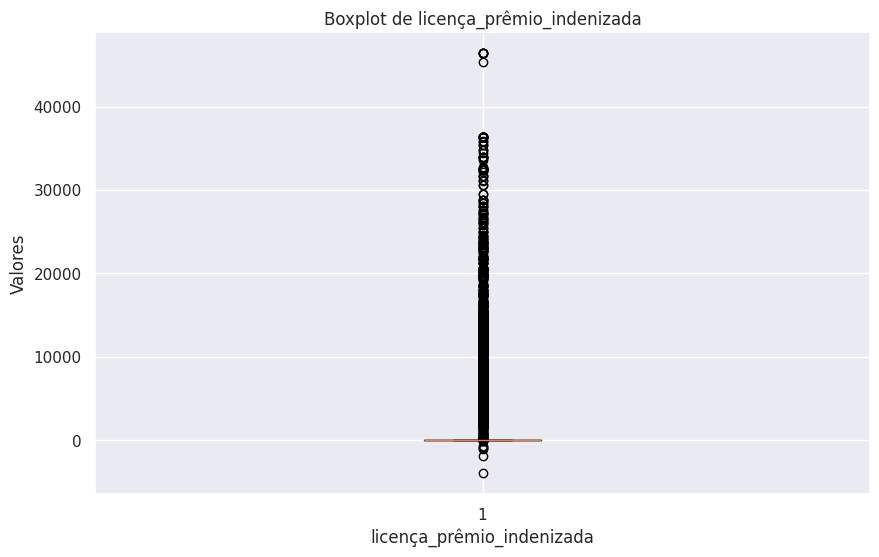

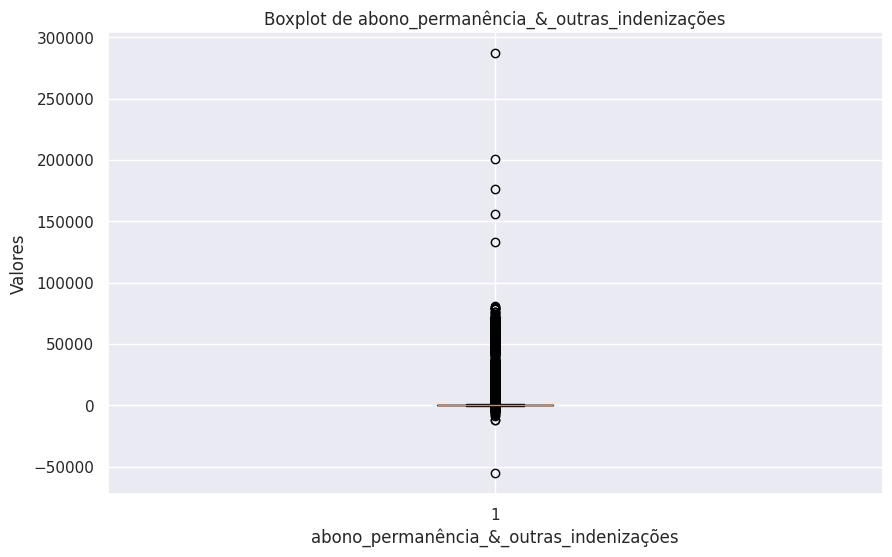

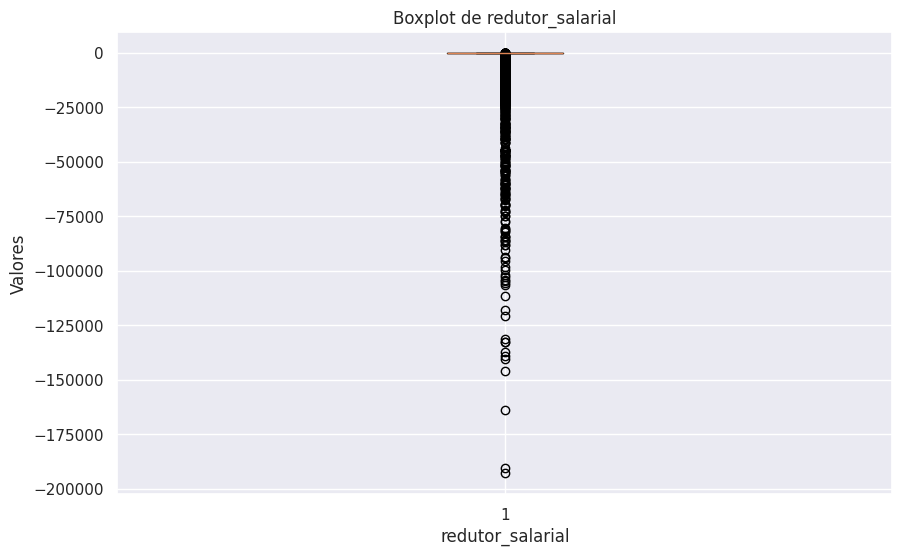

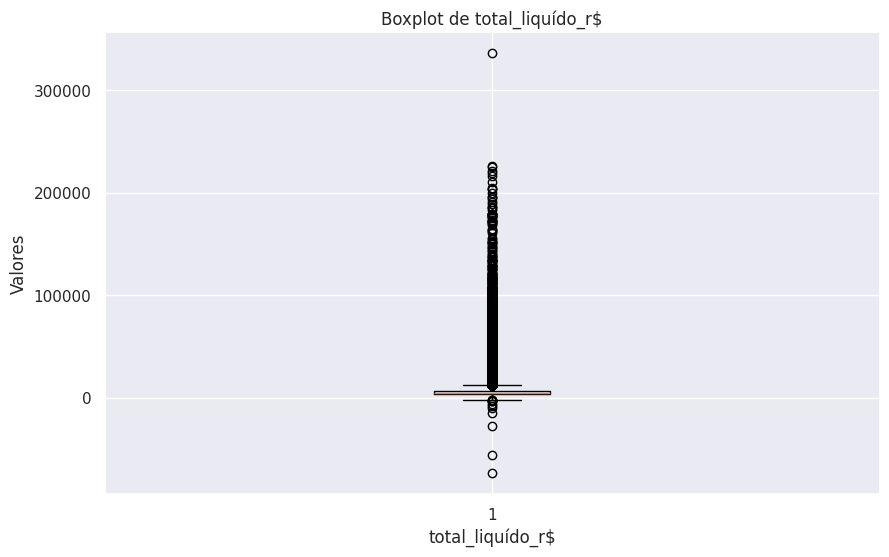

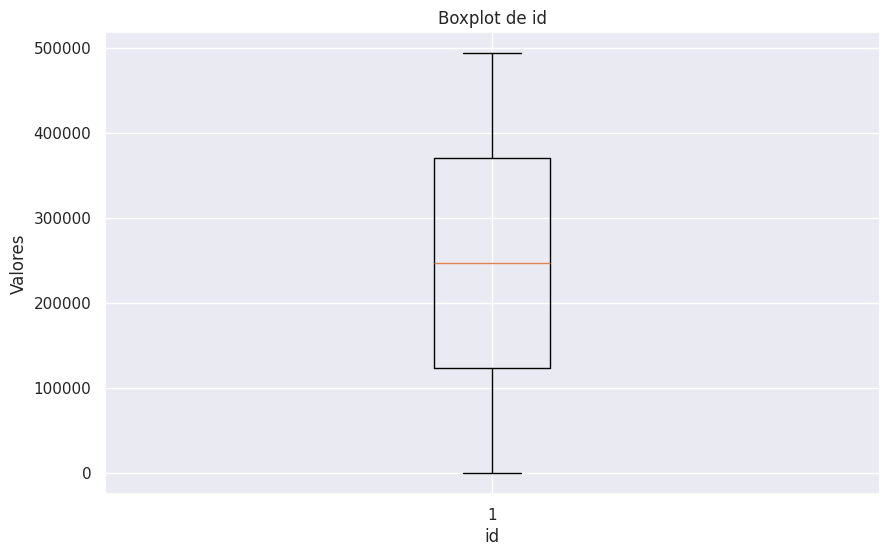

In [68]:
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Gerar boxplots para cada coluna numérica
for column in numeric_df.columns:
    plt.figure(figsize=(10, 6))
    plt.boxplot(numeric_df[column].dropna())
    plt.title(f'Boxplot de {column}')
    plt.xlabel(column)
    plt.ylabel('Valores')
    plt.grid(True)
    plt.show()

**Boxplots com Seaborn**

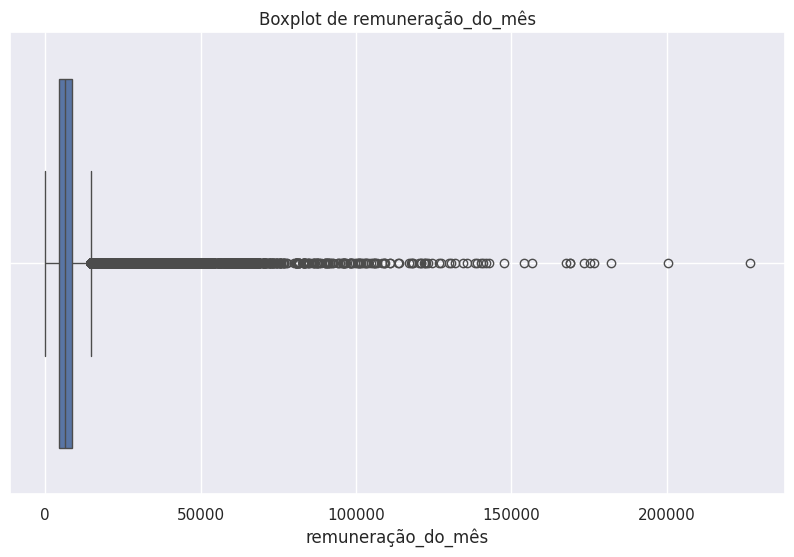

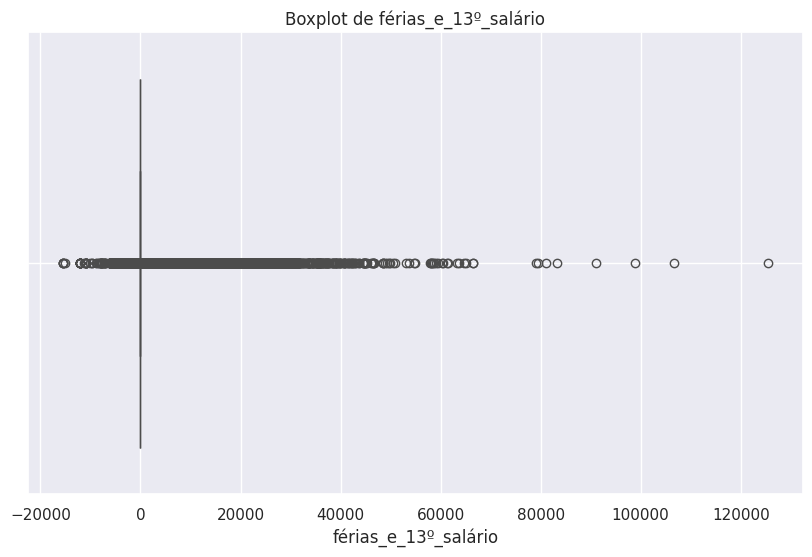

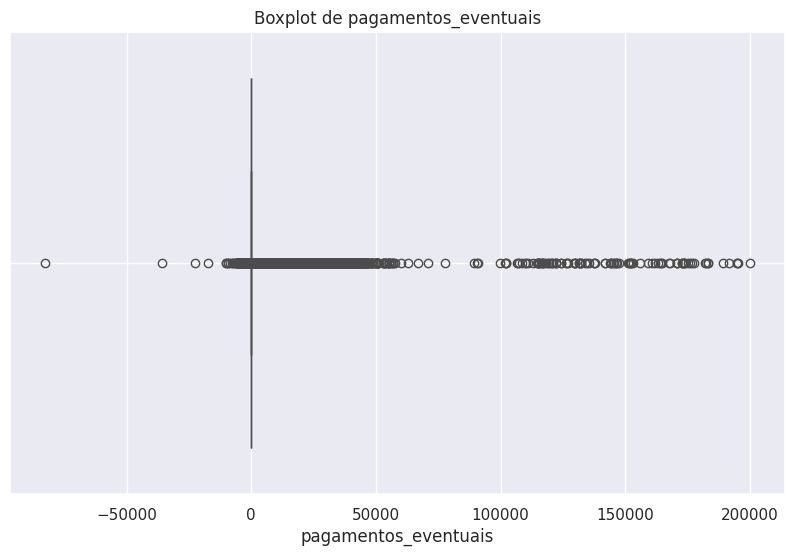

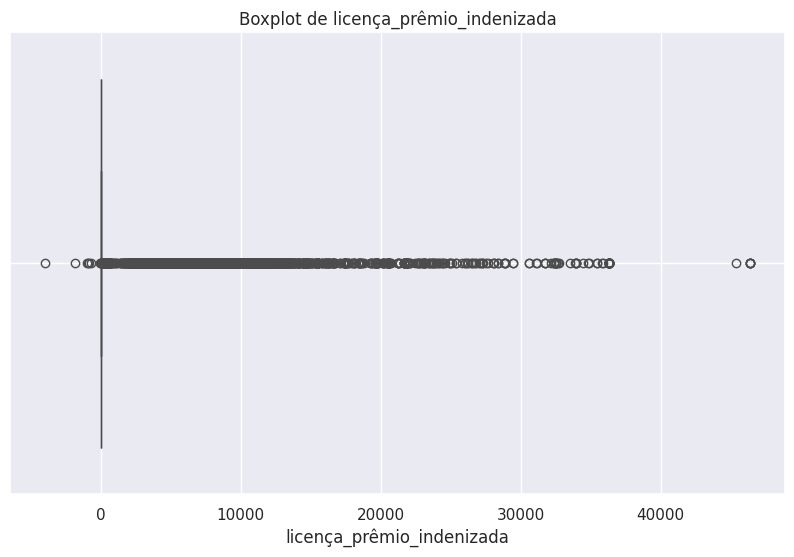

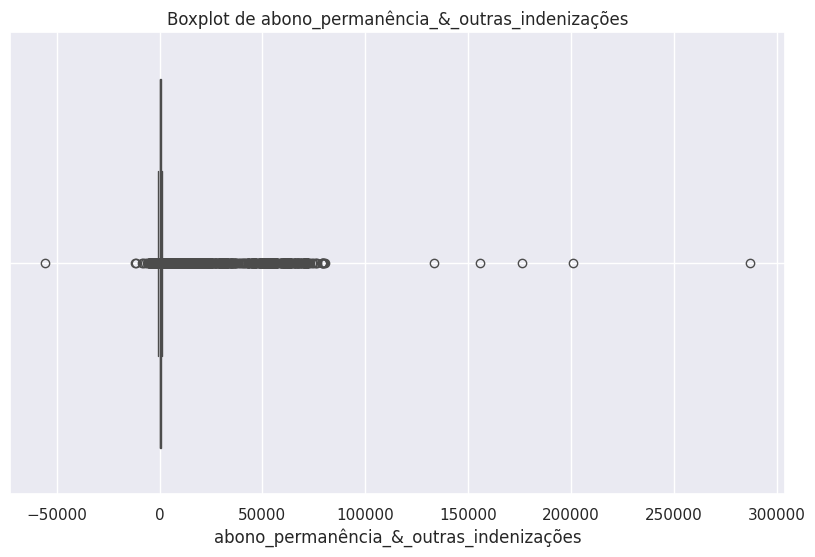

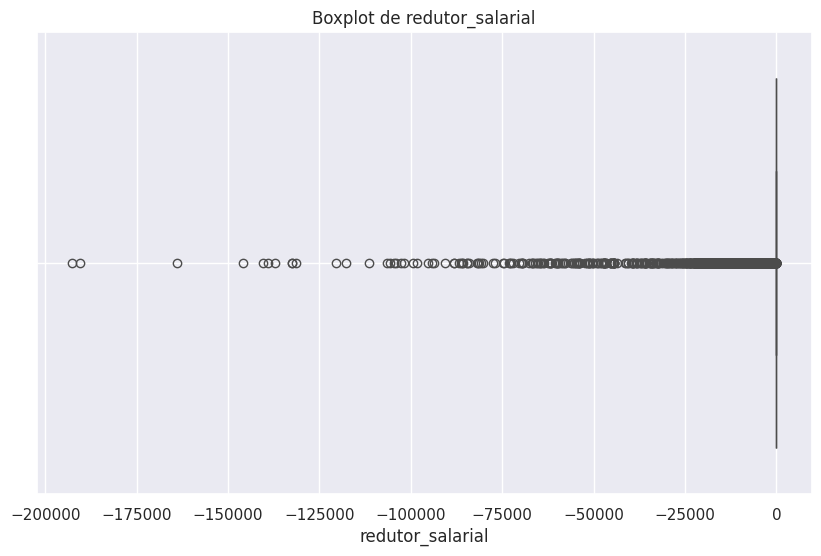

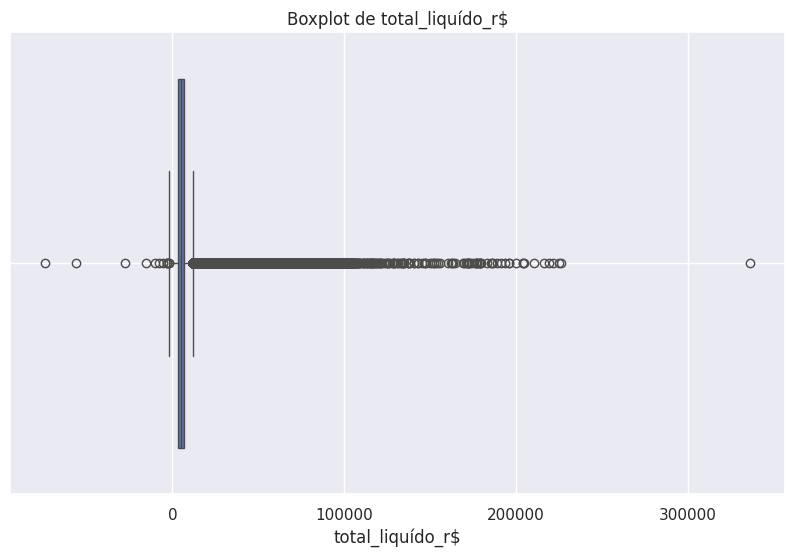

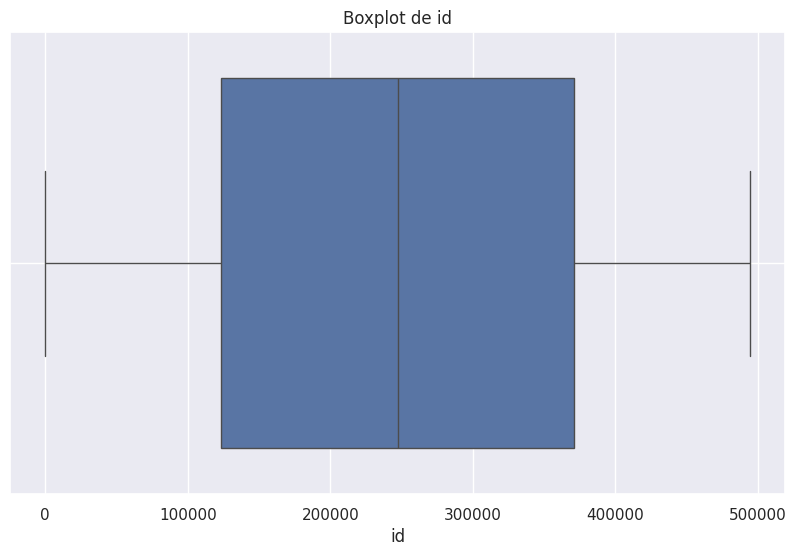

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Gerar boxplots para cada coluna numérica usando seaborn
for column in numeric_df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=numeric_df[column])
    plt.title(f'Boxplot de {column}')
    plt.xlabel(column)
    plt.grid(True)
    plt.show()

**Explicação:**
- plt.boxplot(): Cria um boxplot básico usando matplotlib. O boxplot exibe a mediana, os quartis e possíveis outliers dos dados.
- sns.boxplot(): Cria um boxplot usando seaborn, que oferece uma estética melhor e permite a inclusão de outras variáveis para comparação, se desejado.

Personalização Adicional
- plt.boxplot(): Permite várias personalizações, como adicionar notches (entrecortes) no boxplot para mostrar intervalos de confiança.
- sns.boxplot(): Permite incluir a estética da visualização e pode combinar facilmente com outras variáveis ou facetas.

Esses métodos permitirão visualizar a distribuição, a mediana, e os possíveis outliers para cada variável numérica no seu DataFrame.

**Observando em linha:**

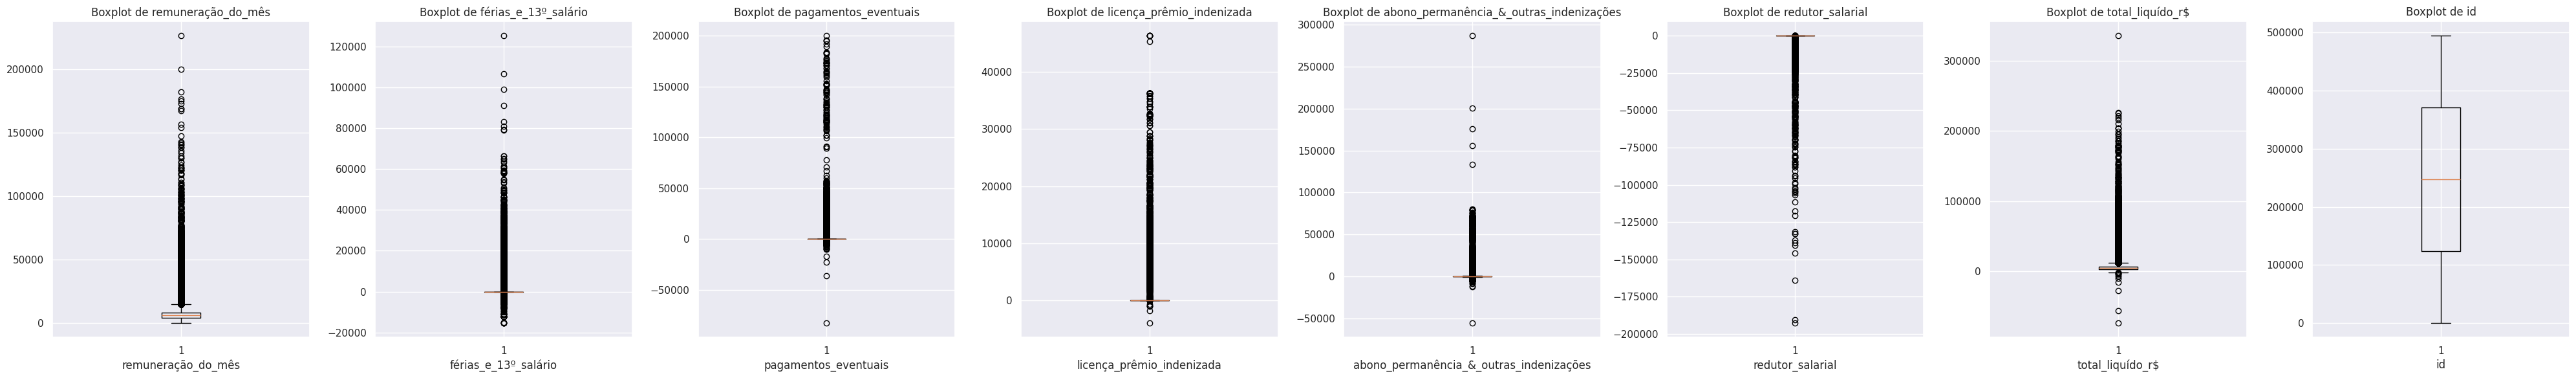

In [70]:
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Definindo o número de subplots com base no número de colunas numéricas
num_vars = len(numeric_df.columns)
fig, axes = plt.subplots(1, num_vars, figsize=(5 * num_vars, 6))  # Ajuste o tamanho conforme necessário

# Gerar boxplots para cada coluna numérica
for ax, column in zip(axes, numeric_df.columns):
    ax.boxplot(numeric_df[column].dropna())
    ax.set_title(f'Boxplot de {column}')
    ax.set_xlabel(column)
    ax.grid(True)

# Ajustar o layout
plt.tight_layout()
plt.show()

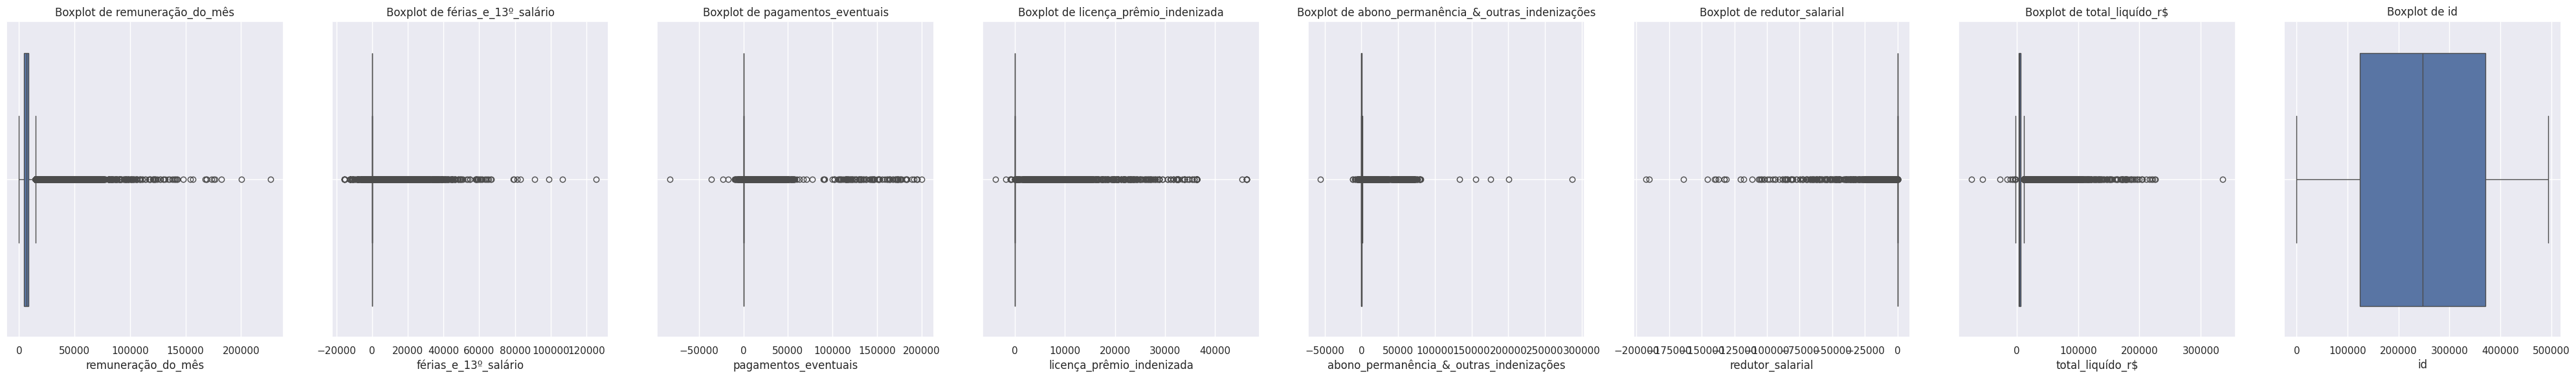

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Definindo o número de subplots com base no número de colunas numéricas
num_vars = len(numeric_df.columns)
fig, axes = plt.subplots(1, num_vars, figsize=(5 * num_vars, 6))  # Ajuste o tamanho conforme necessário

# Gerar boxplots para cada coluna numérica usando seaborn
for ax, column in zip(axes, numeric_df.columns):
    sns.boxplot(x=numeric_df[column], ax=ax)
    ax.set_title(f'Boxplot de {column}')
    ax.set_xlabel(column)
    ax.grid(True)

# Ajustar o layout
plt.tight_layout()
plt.show()

# **4. Discussão**

O que está acontecendo aqui?
Vamos ver:
 - O que acontece com esses salários negativos
 - O que acontece com os salários gigantes

# 4.1. Salários líquidos negativos

Isso deve ser resultado de redutor salarial, não acham?

Ganhou a mais, agora desconta.

In [75]:
#Vamos ver os salários liquídos em relação ao redutor salarial
df[['total_liquído_r$', 'redutor_salarial']].sort_values(by='total_liquído_r$').head(10)

,total_liquído_r$,redutor_salarial
480888,-74083.35,0.0
386704,-55892.93,0.0
353901,-27759.78,0.0
67567,-15296.04,0.0
389257,-10284.45,0.0
29297,-7780.16,0.0
219300,-5777.60,0.0
389474,-3269.88,0.0
86651,-3228.48,0.0
469784,-3138.03,0.0


De onde vieram esses salários negativos?

In [77]:
cols = [
    'remuneração_do_mês',
    'férias_e_13º_salário',
    'pagamentos_eventuais',
    'licença_prêmio_indenizada',
    'abono_permanência_&_outras_indenizações',
    'redutor_salarial',
    'total_liquído_r$'
]

df.loc[
    df['total_liquído_r$'] < 0,
    cols
].head(10)

,remuneração_do_mês,férias_e_13º_salário,pagamentos_eventuais,licença_prêmio_indenizada,abono_permanência_&_outras_indenizações,redutor_salarial,total_liquído_r$
11111,557.37,0.00,0.00,0.0,0.0,0.0,-315.81
14732,114.08,55.65,-2481.79,0.0,0.0,0.0,-2054.85
14866,973.87,-149.34,-868.21,0.0,0.0,0.0,-454.47
29297,336.39,0.00,-4002.33,0.0,0.0,0.0,-7780.16
38785,677.72,0.00,0.00,0.0,0.0,0.0,-24.45
57506,591.15,0.00,0.00,0.0,0.0,0.0,-751.21
67567,6163.98,0.00,-22614.48,0.0,0.0,0.0,-15296.04
67658,0.00,0.00,-12.55,0.0,0.0,0.0,-307.83
71197,2475.78,0.00,-2558.98,0.0,0.0,0.0,-281.71
86651,87.72,0.00,478.01,0.0,0.0,0.0,-3228.48


Parece que encontramos, coluna pagamentos_eventuais.

In [78]:
#Vamos ver os salários liquídos em relação ao redutor salarial
df[['total_liquído_r$', 'pagamentos_eventuais']].sort_values(by='total_liquído_r$').head(10)

,total_liquído_r$,pagamentos_eventuais
480888,-74083.35,-82683.35
386704,-55892.93,-8724.46
353901,-27759.78,-35905.07
67567,-15296.04,-22614.48
389257,-10284.45,-17262.78
29297,-7780.16,-4002.33
219300,-5777.60,-5777.60
389474,-3269.88,-3845.66
86651,-3228.48,478.01
469784,-3138.03,-1581.80


Isso é raro… ou é frequente?

In [80]:
(df['total_liquído_r$'] < 0).sum()

np.int64(42)

Vamos olhar a estatística descritiva desses 42 sujeitos:

In [82]:
df[df['total_liquído_r$'] < 0]['total_liquído_r$'].describe()

,total_liquído_r$
count,42.000000
mean,-5571.401190
std,14467.518774
min,-74083.350000
25%,-2169.057500
50%,-1162.695000
75%,-309.825000
max,-24.450000


**Já imaginou isso indo para algum modelo??**

Quais situações podem gerar salário líquido negativo em folha de pagamento pública?
- Pergunte a LLM

Solução?

In [84]:
#Eu só separaria os negativos por enquanto, até entender o que é isso
df_negativos = df[df['total_liquído_r$'] < 0]
df_positivos = df[df['total_liquído_r$'] >= 0]

Sobre a LLM aqui vai a resposta da minha:
- Veja a associação das variáveis

In [86]:
df[['total_liquído_r$', 'pagamentos_eventuais']].corr()

,total_liquído_r$,pagamentos_eventuais
total_liquído_r$,1.000000,0.463557
pagamentos_eventuais,0.463557,1.000000


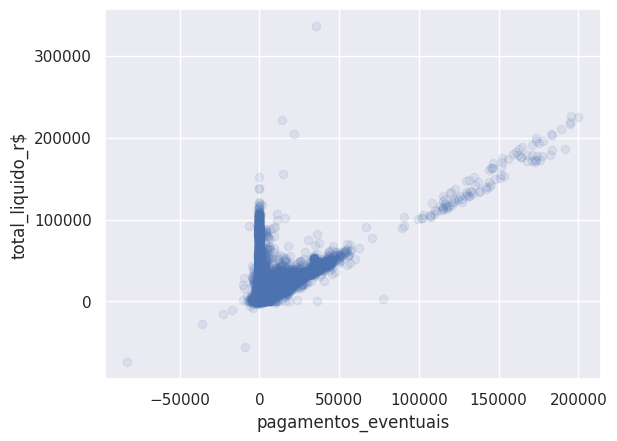

In [88]:
import matplotlib.pyplot as plt

plt.scatter(df['pagamentos_eventuais'], df['total_liquído_r$'], alpha=0.1)
plt.xlabel('pagamentos_eventuais')
plt.ylabel('total_liquido_r$')
plt.show()

**O que descobrimos?**
- O salário líquido é altamente sensível a pagamentos_eventuais
- Se eu ignorar essa variável minha análise fica correta? (não)
- Variáveis com nome ‘eventual’
podem ser as mais importantes do dataset
- Nem tudo que parece bônus… é bônus

**Temos como ter certeza da causa disso?**

HIPÓTESES MAIS PROVÁVEIS
1. Estorno de pagamento anterior
pagaram errado
estão descontando agora
2. Ajuste administrativo
correção de folha
decisão judicial
3. Lançamento acumulado
múltiplos ajustes em um mês

# 4.2. Salários liquídos gigantes

In [91]:
#Vamos ver quem são, estamos só filtrando planilha aqui (só que uma de meio milhão de linhas)
df_top = df.sort_values(by='total_liquído_r$', ascending=False).head(10)
df_top

,nome,cargo,orgão,remuneração_do_mês,férias_e_13º_salário,pagamentos_eventuais,licença_prêmio_indenizada,abono_permanência_&_outras_indenizações,redutor_salarial,total_liquído_r$,id
179743,Juliana Santos,AUDITOR FISCAL DA RECEITA EST,SECRET. FAZENDA PLANEJAMENTO,36445.81,18150.76,35468.00,0.0,286850.36,-144.28,336099.30,179743
350001,Eduardo Nascimento,CIRURGIAO DENTISTA,SECRETARIA DA SAUDE,8992.27,27939.28,195382.23,0.0,0.00,0.00,226292.18,350001
315524,Ana Nascimento,CIRURGIAO DENTISTA,SECRETARIA DA SAUDE,9119.25,26391.16,200013.02,0.0,0.00,0.00,225245.46,315524
368447,Carlos Costa,DELEGADO POLICIA 1A CLASSE,SECRETARIA SEGURANCA PUBLICA,38306.64,8488.44,14280.67,0.0,200776.44,-2005.11,221750.63,368447
192979,Lucas Nascimento,CIRURGIAO DENTISTA,SECRETARIA DA SAUDE,8450.80,27125.17,194927.60,0.0,0.00,0.00,219193.35,192979
360069,Juliana Santos,CIRURGIAO DENTISTA,SECRETARIA DA SAUDE,0.00,24970.65,194742.40,0.0,0.00,0.00,216107.73,360069
178995,Ana Almeida,CIRURGIAO DENTISTA,SECRETARIA DA SAUDE,8244.77,24570.87,189382.81,0.0,0.00,0.00,210644.17,178995
208257,Juliana Silva,CIRURGIAO DENTISTA,SECRETARIA DA SAUDE,8007.22,22649.11,182595.17,0.0,0.00,0.00,204544.16,208257
235667,Ana Souza,ESPECIALISTA AGROPECUARIO VI,SECR.AGRICULTURA ABASTECIMENTO,20496.15,0.00,21803.39,0.0,176257.99,0.00,204060.03,235667
300699,Helena Nascimento,CIRURGIAO DENTISTA,SECRETARIA DA SAUDE,8804.01,25242.22,183208.04,0.0,0.00,0.00,203844.80,300699


E ai LLM? O que isso significa?

**Esses casos têm padrão muito interessante:**
- O driver principal NÃO é salário base
- remuneração_do_mês → ~8k a 36k
- total_liquido → 200k+

**impossível vir do salário base**

- Quem está dominando?

👉 pagamentos_eventuais
👉 indenizações

**CONCLUSÃO PRINCIPAL**

🔥 Esses valores NÃO são salários mensais
🔥 São eventos extraordinários acumulados

**Grupo dominante:**

CIRURGIÃO DENTISTA – Secretaria da Saúde

**Por que esse grupo específico aparece tanto?**

🧠 HIPÓTESES FORTES
1. 🔥 Pagamentos retroativos
acúmulo de meses/anos
2. 🔥 Ações judiciais
decisões liberando valores
3. 🔥 Indenizações acumuladas
férias
benefícios
4. 🔥 Mudança de regime/contrato

In [92]:
df_top['cargo'].value_counts()

,count
cargo,
CIRURGIAO DENTISTA,7
AUDITOR FISCAL DA RECEITA EST,1
DELEGADO POLICIA 1A CLASSE,1
ESPECIALISTA AGROPECUARIO VI,1


In [94]:
df.groupby('cargo')['total_liquído_r$'].mean().sort_values(ascending=False).head(10)

,total_liquído_r$
cargo,
PROCURADOR GERAL DO ESTADO,96587.100000
PROC.GERAL DO ESTADO ADJUNTO,93867.510000
PROCURADOR ESTADO CORREG.GERAL,93151.670000
PROCURADOR DO ESTADO ASSESSOR,79878.154545
PROCURADOR DO ESTADO CHEFE,79505.850476
SUBPROCURADOR GERAL DO ESTADO,78780.286667
PROCURADOR ESTADO ASSISTENTE,76532.571290
PROCURADOR DO ESTADO NIVEL V,75300.859217
PROCURADOR ESTADO ASS. CHEFE,73434.860000


In [95]:
(df['pagamentos_eventuais'] > 100000).sum()

np.int64(101)

MOMENTO LLM

Quais situações explicam pagamentos eventuais muito altos em servidores públicos?

# **5. Mergulho profundo**

Nós vamos agora tentar entender como as colunas contribuem para o total líquido

**1 — Criar as proporções**

In [105]:
componentes = [
    'remuneração_do_mês',
    'férias_e_13º_salário',
    'pagamentos_eventuais',
    'licença_prêmio_indenizada',
    'abono_permanência_&_outras_indenizações',
    'redutor_salarial'
]

for col in componentes:
    df[f'perc_{col}'] = df[col] / df['total_liquído_r$']

In [106]:
#Pode ter zeros, isso aqui evita divisão por zero
for col in componentes:
    df[f'perc_{col}'] = df[col] / df['total_liquído_r$'].replace(0, None)

**2 — Analisando salários mais altos**

Aqui estamos vendo proporcionalmente os salários extremos, veja que interessante:

In [107]:
df_top = df.sort_values(by='total_liquído_r$', ascending=False).head(10)

cols_perc = [f'perc_{col}' for col in componentes]

df_top[cols_perc]

,perc_remuneração_do_mês,perc_férias_e_13º_salário,perc_pagamentos_eventuais,perc_licença_prêmio_indenizada,perc_abono_permanência_&_outras_indenizações,perc_redutor_salarial
179743,0.108438,0.054004,0.105528,0.0,0.853469,-0.000429
350001,0.039737,0.123466,0.863407,0.0,0.0,0.0
315524,0.040486,0.117166,0.887978,0.0,0.0,0.0
368447,0.172746,0.038279,0.0644,0.0,0.905415,-0.009042
192979,0.038554,0.12375,0.889295,0.0,0.0,0.0
360069,0.0,0.115547,0.901136,0.0,0.0,0.0
178995,0.039141,0.116646,0.899065,0.0,0.0,0.0
208257,0.039147,0.11073,0.892693,0.0,0.0,0.0
235667,0.100442,0.0,0.106848,0.0,0.863756,0.0
300699,0.04319,0.123831,0.898762,0.0,0.0,0.0


O que acha, conorda?
 - pagamentos_eventuais → dominante
 - abonos grandes
 - salário base pequeno proporcionalmente

**3 - Visão global**

In [108]:
df[cols_perc].mean().sort_values(ascending=False)

,0
perc_remuneração_do_mês,4.854942
perc_férias_e_13º_salário,2.270561
perc_pagamentos_eventuais,0.332164
perc_abono_permanência_&_outras_indenizações,0.060782
perc_licença_prêmio_indenizada,0.003445
perc_redutor_salarial,-0.001882


**Esses valores não deveriam somar ~1?**
 - totais muito pequenos / negativos
 - proporções “explodindo”
 - efeito de divisão instável

Veja as proporções dos super salários:

In [110]:
df_extremos = df[df['total_liquído_r$'] > 100000]

df_extremos[cols_perc].mean()

,0
perc_remuneração_do_mês,0.252894
perc_férias_e_13º_salário,0.12826
perc_pagamentos_eventuais,0.553564
perc_licença_prêmio_indenizada,0.019626
perc_abono_permanência_&_outras_indenizações,0.230575
perc_redutor_salarial,-0.042007


Veja que temos uma tendência diferente.


 - **Isso significa que não podemos analisar tudo junto?**

- **Estamos olhando um único fenômeno, ou vários fenômenos misturados?**

- **Se eu treinar um modelo com tudo junto…
ele aprende o quê?**

**TRADUÇÃO CONCEITUAL**

🔹 Dataset geral:
dominado por salário base
comportamento “normal”

🔹 Extremos:
dominados por eventos
comportamento “anômalo” (mas real)

Possível solução:
- Separar os eventos

In [111]:
df_normal = df[df['pagamentos_eventuais'] < 10000]
df_evento = df[df['pagamentos_eventuais'] >= 10000]

Não esqueça que deixamos os negativos la atrás separados

# **6. Critérios de fracionamento usando estatística**

Nós vamo sutilizar tecnicoas de remoção de outliers para visualizar como seria o dataset sem esses extremos.

Essa é uma etapa comum na limpeza e pré-processamento de dados. Mas sempre cuidado, pois os extremos podem carregar informações importantes, como observamos nas etapas anteriores.

Existem várias maneiras de identificar e remover outliers, porém a existência de um outlier não necessáriamente indica que o dado precisa ser removido.

Atenção em cuidado na análise dos outliers antes de remove-los.

    Desvio Padrão
    Intervalo Interquartil (IQR)
    Boxplots - já utilizamos
   
Sempre busque analisar e visualizar os Outliers antes de remove-los, realize a análise variável por variável, e se for necessário, utilizando o dataframe completo.

# **6.1 Abordagem utilizando IQR**

**Removendo utilizando o Intervalo Interquartil (IQR)**

Uma abordagem que considerara dados que estão acima ou abaixo do IQR como outliers.

Explicação:
- Calcular Q1, Q3 e IQR: Calcula o primeiro quartil (Q1), o terceiro quartil (Q3) e o intervalo interquartil (IQR) para a coluna especificada.
- Definir Limite Superior:
Valores acima desse limite são considerados outliers superiores.
- Definir Limite Inferior:
Valores acima abaixo limite são considerados outliers inferiores.
- Filtrar o DataFrame: Filtra o DataFrame para manter apenas as linhas onde o valor na coluna especificada é menor ou igual ao limite superior.
- Depois salvamos os extremos e removemos do dataset

**6.1 Abordagem utilizando IQR - para outliers superiores ao IQR.**

In [112]:
def filter_above_iqr_for_column(df, column_name):
    # Calcular Q1, Q3 e IQR
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1

    # Limite superior
    upper_bound = Q3 + 1.5 * IQR

    # Filtrar valores acima do limite superior
    column_outliers = df[df[column_name] > upper_bound]

    return column_outliers

# Filtrar valores superiores ao IQR para a coluna 'XXXX'
outliers_up = filter_above_iqr_for_column(df, 'total_liquído_r$')

# Exibir os resultados
print("Valores superiores ao IQR na coluna 'total_liquído_r$':")
outliers_up

Valores superiores ao IQR na coluna 'total_liquído_r$':


,nome,cargo,orgão,remuneração_do_mês,férias_e_13º_salário,pagamentos_eventuais,licença_prêmio_indenizada,abono_permanência_&_outras_indenizações,redutor_salarial,total_liquído_r$,id,perc_remuneração_do_mês,perc_férias_e_13º_salário,perc_pagamentos_eventuais,perc_licença_prêmio_indenizada,perc_abono_permanência_&_outras_indenizações,perc_redutor_salarial
5,Helena Rodrigues,1TEN PM,POLICIA MILITAR SAO PAULO,16151.29,2470.63,0.00,0.00,768.40,0.0,14625.56,5,1.104319,0.168925,0.0,0.0,0.052538,0.0
6,Mariana Costa,CABO PM,POLICIA MILITAR SAO PAULO,8552.50,3576.06,0.00,7937.78,922.08,0.0,16383.10,6,0.522032,0.218277,0.0,0.48451,0.056282,0.0
27,Fernanda Pereira,MEDICO III,SECRETARIA DA SAUDE,20113.11,3224.42,121.93,0.00,0.00,0.0,17067.04,27,1.178477,0.188927,0.007144,0.0,0.0,0.0
59,Bruno Oliveira,MEDICO I,HOSP.CLIN.FAC.MED.USP-HCFMUSP,21273.53,0.00,2853.76,0.00,0.00,0.0,18350.41,59,1.159295,0.0,0.155515,0.0,0.0,0.0
62,Helena Almeida,MEDICO II,SECRETARIA DA SAUDE,26634.89,9332.81,1.61,0.00,2419.79,0.0,21011.98,62,1.267605,0.444166,0.000077,0.0,0.115162,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494186,Gabriel Oliveira,DIRETOR DE ESCOLA,SECRETARIA DA EDUCACAO,15813.25,8191.62,11974.98,0.00,3714.50,0.0,26194.66,494186,0.603682,0.312721,0.457153,0.0,0.141804,0.0
494189,Mariana Oliveira,PROFESSOR EDUCACAO BASICA II,SECRETARIA DA EDUCACAO,3797.20,0.00,2171.54,0.00,23130.19,0.0,25525.71,494189,0.14876,0.0,0.085073,0.0,0.906153,0.0
494196,Bruno Almeida,CCESP 2.08-ASSIST TECNICO IV,SECRET. FAZENDA PLANEJAMENTO,14359.29,7179.64,0.00,0.00,0.00,0.0,16259.83,494196,0.883114,0.441557,0.0,0.0,0.0,0.0
494197,Mariana Oliveira,DELEGADO POLICIA 1A CLASSE,SECRETARIA SEGURANCA PUBLICA,34185.35,25430.89,424.83,0.00,7019.82,0.0,48007.56,494197,0.712083,0.529727,0.008849,0.0,0.146223,0.0


**6.2. Abordagem utilizando IQR - para outliers inferiores ao IQR.**

In [113]:
def filter_below_iqr_for_column(df, column_name):
    # Calcular Q1, Q3 e IQR
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1

    # Limite inferior
    lower_bound = Q1 - 1.5 * IQR

    # Filtrar valores abaixo do limite inferior
    column_outliers = df[df[column_name] < lower_bound]

    return column_outliers

# Filtrar valores abaixo do IQR para a coluna 'XXXX'
outliers_low = filter_below_iqr_for_column(df, 'total_liquído_r$')

# Exibir os resultados
print("Valores abaixo do IQR na coluna 'total_liquído_r$':")
outliers_low

Valores abaixo do IQR na coluna 'total_liquído_r$':


,nome,cargo,orgão,remuneração_do_mês,férias_e_13º_salário,pagamentos_eventuais,licença_prêmio_indenizada,abono_permanência_&_outras_indenizações,redutor_salarial,total_liquído_r$,id,perc_remuneração_do_mês,perc_férias_e_13º_salário,perc_pagamentos_eventuais,perc_licença_prêmio_indenizada,perc_abono_permanência_&_outras_indenizações,perc_redutor_salarial
29297,Bruno Almeida,AGENTE DE ORGANIZACAO ESCOLAR,SECRETARIA DA EDUCACAO,336.39,0.00,-4002.33,0.0,0.00,0.0,-7780.16,29297,-0.043237,-0.0,0.514428,-0.0,-0.0,-0.0
67567,Fernanda Almeida,PROFESSOR EDUCACAO BASICA I,SECRETARIA DA EDUCACAO,6163.98,0.00,-22614.48,0.0,0.00,0.0,-15296.04,67567,-0.402979,-0.0,1.478453,-0.0,-0.0,-0.0
86651,Carlos Rodrigues,OFICIAL ADMINISTRATIVO,SECRETARIA DA SAUDE,87.72,0.00,478.01,0.0,0.00,0.0,-3228.48,86651,-0.027171,-0.0,-0.14806,-0.0,-0.0,-0.0
219300,Helena Nascimento,MEDICO II,SECRETARIA DA SAUDE,0.00,0.00,-5777.60,0.0,0.00,0.0,-5777.60,219300,-0.0,-0.0,1.0,-0.0,-0.0,-0.0
232825,Gabriel Souza,PROFESSOR EDUCACAO BASICA II,SECRETARIA DA EDUCACAO,0.00,0.00,856.68,0.0,120.41,0.0,-2131.43,232825,-0.0,-0.0,-0.401927,-0.0,-0.056493,-0.0
350216,Ana Oliveira,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,83.47,-177.63,-2442.24,0.0,0.00,0.0,-2181.60,350216,-0.038261,0.081422,1.119472,-0.0,-0.0,-0.0
353901,Daniela Costa,PROFESSOR EDUCACAO BASICA II,SECRETARIA DA EDUCACAO,3778.88,0.00,-35905.07,0.0,0.00,0.0,-27759.78,353901,-0.136128,-0.0,1.293421,-0.0,-0.0,-0.0
386704,Mariana Nascimento,DIRETOR ESCOLAR,SECRETARIA DA EDUCACAO,9310.15,0.00,-8724.46,0.0,-55557.50,0.0,-55892.93,386704,-0.166571,-0.0,0.156092,-0.0,0.993999,-0.0
389257,Ana Nascimento,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,5286.75,0.00,-17262.78,0.0,0.00,0.0,-10284.45,389257,-0.514053,-0.0,1.678532,-0.0,-0.0,-0.0
389474,Helena Oliveira,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,361.72,285.21,-3845.66,0.0,0.00,0.0,-3269.88,389474,-0.110622,-0.087223,1.176086,-0.0,-0.0,-0.0


Agora que separamos eles, vamos remover do dataset e visualizar.

**Removendo Ouliers maiores do que o IQR**

In [114]:
def remove_above_iqr_for_column(df, column_name):
    # Calcular Q1, Q3 e IQR
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1

    # Limite superior
    upper_bound = Q3 + 1.5 * IQR

    # Filtrar valores abaixo do limite superior
    filtered_df = df[df[column_name] <= upper_bound]

    return filtered_df

# Remover valores acima do IQR para a coluna 'MSRP'
cleaned_df = remove_above_iqr_for_column(df, 'total_liquído_r$')

# Exibir os resultados
print("DataFrame após remover os valores acima do IQR na coluna 'total_liquído_r$':")
cleaned_df

DataFrame após remover os valores acima do IQR na coluna 'total_liquído_r$':


,nome,cargo,orgão,remuneração_do_mês,férias_e_13º_salário,pagamentos_eventuais,licença_prêmio_indenizada,abono_permanência_&_outras_indenizações,redutor_salarial,total_liquído_r$,id,perc_remuneração_do_mês,perc_férias_e_13º_salário,perc_pagamentos_eventuais,perc_licença_prêmio_indenizada,perc_abono_permanência_&_outras_indenizações,perc_redutor_salarial
0,Carlos Oliveira,ESTAGIARIO,FUND.PE.ANCHIETA-C.P.RADIO TV.,1400.00,0.00,0.0,0.0,0.00,0.0,1400.00,0,1.0,0.0,0.0,0.0,0.0,0.0
1,Igor Santos,SD 1C PM,POLICIA MILITAR SAO PAULO,5571.16,4249.80,0.0,0.0,1152.60,0.0,7385.42,1,0.754346,0.575431,0.0,0.0,0.156064,0.0
2,Lucas Rodrigues,CAP PM,POLICIA MILITAR SAO PAULO,17445.85,0.00,0.0,0.0,307.36,0.0,8013.77,2,2.176984,0.0,0.0,0.0,0.038354,0.0
3,Helena Santos,POLICIAL PENAL I,SECRETARIA ADM.PENITENCIARIA,5481.27,0.00,0.0,0.0,0.00,0.0,3855.71,3,1.421598,0.0,0.0,0.0,0.0,0.0
4,Eduardo Costa,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,7791.00,0.00,0.0,0.0,0.00,0.0,5953.34,4,1.308677,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494238,Juliana Rodrigues,OFICIAL ADMINISTRATIVO,DEPT.ESTAD.TRANSITO DETRAN SP,3469.96,0.00,0.0,0.0,241.20,0.0,3102.80,494238,1.118332,0.0,0.0,0.0,0.077736,0.0
494239,Fernanda Almeida,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,5328.71,0.00,0.0,0.0,0.00,0.0,4660.62,494239,1.143348,0.0,0.0,0.0,0.0,0.0
494240,Ana Oliveira,PROFESSOR EDUCACAO BASICA I,SECRETARIA DA EDUCACAO,5681.13,2840.56,0.0,0.0,0.00,0.0,7081.61,494240,0.802237,0.401118,0.0,0.0,0.0,0.0
494241,Eduardo Costa,CABO PM,POLICIA MILITAR SAO PAULO,7937.78,0.00,0.0,0.0,1075.76,0.0,5056.37,494241,1.569857,0.0,0.0,0.0,0.212753,0.0


**Removendo Ouliers menores do que o IQR**

In [ ]:
def remove_below_iqr_for_column(df, column_name):
    # Calcular Q1, Q3 e IQR
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1

    # Limite inferior
    lower_bound = Q1 - 1.5 * IQR

    # Filtrar valores abaixo do limite inferior
    filtered_df = df[df[column_name] >= lower_bound]

    return filtered_df

# Remover valores abaixo do IQR para a coluna 'Year'
cleaned_df = remove_below_iqr_for_column(cleaned_df, 'total_liquído_r$')

# Exibir os resultados
print("DataFrame após remover os valores abaixo do IQR na coluna 'total_liquído_r$':")
print(cleaned_df)

Vamos ver novamente os dados

<Axes: ylabel='total_liquído_r$'>

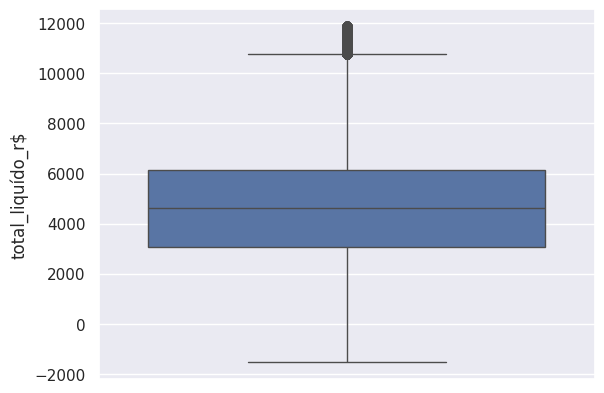

In [117]:
sns.boxplot(cleaned_df['total_liquído_r$'])

<Axes: >

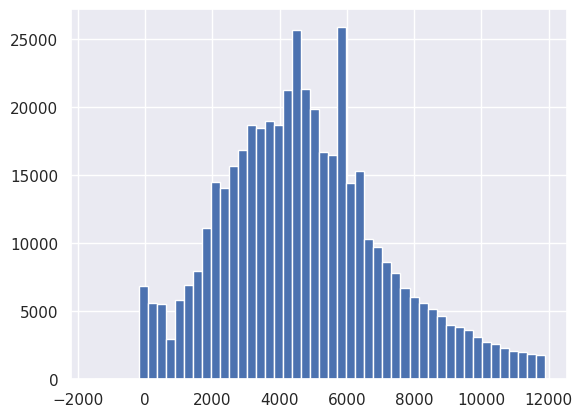

In [118]:
cleaned_df['total_liquído_r$'].hist(bins=50)

Bem diferente não?

# **6.2. Abordagem utilizando desvio padrão**

Explicação:
- Calcular Média e Desvio Padrão: A função remove_above_std_for_column calcula a média (mean) e o desvio padrão (std_dev) da coluna especificada.
- Definir Limite Superior: O limite superior é calculado para identificar valores que estão significativamente acima da média. Você pode ajustar esse fator se necessário.
- Definir Limite Inferior: O limite inferior é calculado para identificar valores que estão significativamente abaixo da média. Você pode ajustar esse fator se necessário.
- Filtrar o DataFrame: Filtra o DataFrame para salvar o extremos.
- Depois limpamos o dataset para remover os extremos.

**6.2 Abordagem utilizando desvio padrão - para outliers superiores a 3 desvio padrão.**

In [120]:
def filter_above_iqr_for_column(df, column_name):
    # Calcular média e desvio padrão
    mean = df[column_name].mean()
    std_dev = df[column_name].std()

    # Limite inferior
    upper_bound = mean + 3 * std_dev

    # Filtrar valores acima do limite superior
    column_outliers = df[df[column_name] > upper_bound]

    return column_outliers

# Filtrar valores superiores ao IQR para a coluna 'XXXX'
outliers_up = filter_above_iqr_for_column(df, 'total_liquído_r$')

# Exibir os resultados
print("Valores superiores ao IQR na coluna 'total_liquído_r$':")
print(outliers_up)

Valores superiores ao IQR na coluna 'total_liquído_r$':
                     nome                          cargo  \
79      Fernanda Oliveira                   ARQUITETO VI   
137       Eduardo Pereira      CCESP 1.05-CHEFE DE SECAO   
166        Gabriel Santos  AUDITOR FISCAL DA RECEITA EST   
220           Bruno Souza   PROCURADOR DO ESTADO NIVEL I   
268       Daniela Pereira  AUDITOR FISCAL DA RECEITA EST   
...                   ...                            ...   
494025       Ana Oliveira  PROCURADOR DO ESTADO NIVEL II   
494106   Carlos Rodrigues                  ENGENHEIRO II   
494186   Gabriel Oliveira              DIRETOR DE ESCOLA   
494189   Mariana Oliveira   PROFESSOR EDUCACAO BASICA II   
494197   Mariana Oliveira     DELEGADO POLICIA 1A CLASSE   

                                 orgão  remuneração_do_mês  \
79         SEC.MEIO AMB. INFRA.LOGIST.           120828.70   
137     SECRETARIA GESTAO GOVERNO DIG.            16430.25   
166       SECRET. FAZENDA PLANEJAMENT

**6.2 Abordagem utilizando desvio padrão - para outliers inferiores a 3 desvio padrão.**

In [121]:
def filter_below_std_for_column(df, column_name):
    # Calcular média e desvio padrão
    mean = df[column_name].mean()
    std_dev = df[column_name].std()

    # Limite inferior
    lower_bound = mean - 3 * std_dev

    # Filtrar valores abaixo do limite inferior
    column_outliers = df[df[column_name] < lower_bound]

    return column_outliers

# Filtrar valores abaixo do desvio padrão para a coluna 'MSRP'
outliers = filter_below_std_for_column(df, 'total_liquído_r$')

# Exibir os resultados
print("Valores abaixo do desvio padrão na coluna 'total_liquído_r$':")
print(outliers)

Valores abaixo do desvio padrão na coluna 'total_liquído_r$':
                      nome                         cargo  \
67567     Fernanda Almeida   PROFESSOR EDUCACAO BASICA I   
353901       Daniela Costa  PROFESSOR EDUCACAO BASICA II   
386704  Mariana Nascimento               DIRETOR ESCOLAR   
480888      Ana Nascimento        ANALISTA DE TECNOLOGIA   

                         orgão  remuneração_do_mês  férias_e_13º_salário  \
67567   SECRETARIA DA EDUCACAO             6163.98                  0.00   
353901  SECRETARIA DA EDUCACAO             3778.88                  0.00   
386704  SECRETARIA DA EDUCACAO             9310.15                  0.00   
480888  SECRETARIA DA EDUCACAO             2466.24              -5423.05   

        pagamentos_eventuais  licença_prêmio_indenizada  \
67567              -22614.48                        0.0   
353901             -35905.07                        0.0   
386704              -8724.46                        0.0   
480888             -

**6.2. Removendo outliers utilizando o Desvio Padrão**

Uma abordagem simples é considerar dados que estão a mais de 2 ou 3 desvios padrões da média como outliers.

**Removendo Ouliers maiores do que 3 desvio padrão**

In [122]:
def remove_above_std_for_column(df, column_name):
    # Calcular média e desvio padrão
    mean = df[column_name].mean()
    std_dev = df[column_name].std()

    # Limite superior
    upper_bound = mean + 3 * std_dev

    # Filtrar valores abaixo do limite superior
    filtered_df = df[df[column_name] <= upper_bound]

    return filtered_df

# Remover valores acima do desvio padrão para a coluna 'MSRP'
cleaned_df_sd = remove_above_std_for_column(df, 'total_liquído_r$')

# Exibir os resultados
print("DataFrame após remover os valores acima do desvio padrão na coluna 'total_liquído_r$':")
print(cleaned_df_sd)

DataFrame após remover os valores acima do desvio padrão na coluna 'total_liquído_r$':
                     nome                          cargo  \
0         Carlos Oliveira                     ESTAGIARIO   
1             Igor Santos                       SD 1C PM   
2         Lucas Rodrigues                       CAP   PM   
3           Helena Santos               POLICIAL PENAL I   
4           Eduardo Costa  PROF ENSINO FUNDAMENTAL/MEDIO   
...                   ...                            ...   
494238  Juliana Rodrigues         OFICIAL ADMINISTRATIVO   
494239   Fernanda Almeida  PROF ENSINO FUNDAMENTAL/MEDIO   
494240       Ana Oliveira    PROFESSOR EDUCACAO BASICA I   
494241      Eduardo Costa                       CABO  PM   
494242     Carlos Pereira  PROF ENSINO FUNDAMENTAL/MEDIO   

                                 orgão  remuneração_do_mês  \
0       FUND.PE.ANCHIETA-C.P.RADIO TV.             1400.00   
1            POLICIA MILITAR SAO PAULO             5571.16   
2     

**Removendo Ouliers menores do que 3 desvio padrão**

In [123]:
def remove_below_std_for_column(df, column_name):
    # Calcular média e desvio padrão
    mean = df[column_name].mean()
    std_dev = df[column_name].std()

    # Limite inferior
    lower_bound = mean - 3 * std_dev

    # Filtrar valores acima do limite inferior
    filtered_df = df[df[column_name] >= lower_bound]

    return filtered_df

# Remover valores abaixo de 3 desvios padrão para a coluna 'MSRP'
cleaned_df_sd = remove_below_std_for_column(cleaned_df_sd, 'total_liquído_r$')

# Exibir os resultados
print("DataFrame após remover os valores abaixo de 3 desvios padrão na coluna 'total_liquído_r$':")
print(cleaned_df_sd)

DataFrame após remover os valores abaixo de 3 desvios padrão na coluna 'total_liquído_r$':
                     nome                          cargo  \
0         Carlos Oliveira                     ESTAGIARIO   
1             Igor Santos                       SD 1C PM   
2         Lucas Rodrigues                       CAP   PM   
3           Helena Santos               POLICIAL PENAL I   
4           Eduardo Costa  PROF ENSINO FUNDAMENTAL/MEDIO   
...                   ...                            ...   
494238  Juliana Rodrigues         OFICIAL ADMINISTRATIVO   
494239   Fernanda Almeida  PROF ENSINO FUNDAMENTAL/MEDIO   
494240       Ana Oliveira    PROFESSOR EDUCACAO BASICA I   
494241      Eduardo Costa                       CABO  PM   
494242     Carlos Pereira  PROF ENSINO FUNDAMENTAL/MEDIO   

                                 orgão  remuneração_do_mês  \
0       FUND.PE.ANCHIETA-C.P.RADIO TV.             1400.00   
1            POLICIA MILITAR SAO PAULO             5571.16   
2 

**Tarefa:**
- Compare os resutlados da abordagem IQR, desvio padrão e SVM para uma variável, refazendo a análise exploratório após a remoção de outliers.**

<Axes: ylabel='total_liquído_r$'>

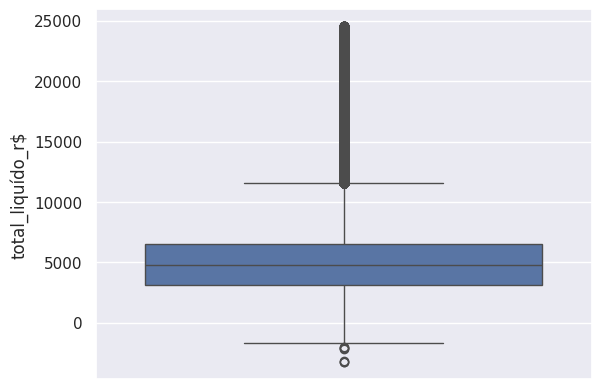

In [125]:
sns.boxplot(cleaned_df_sd['total_liquído_r$'])

<Axes: >

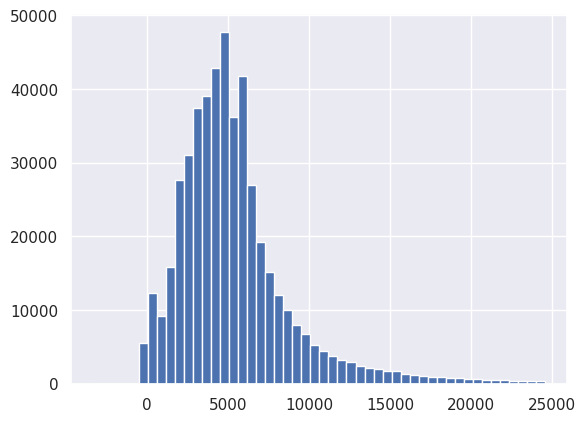

In [126]:
cleaned_df_sd['total_liquído_r$'].hist(bins=50)

**Resumo**

Escolher o método apropriado depende do contexto e dos requisitos da análise. O método do desvio padrão é simples e rápido, enquanto o IQR é mais robusto e frequentemente usado para dados não normalmente distribuídos.

Os Boxplots são úteis para visualização da distribuição de valores em relação a extremos e histogramas permite verificar como ocorre a distribuição dos valores em termos de frequência.

O que acha?

Viu como só o uso da EDA já permite conhecer muito sobre o dataset?

Acha que após a análise você tomaria decisões diferentes de como trabalhar esses dados?

Na aula que vem amos ver o que acontece a partir disso.